Add photon loss, coherence

In [20]:
import qutip as qt
from qutip import *
import matplotlib.pyplot as plt
import numpy as np

## general solution for g(t)

In [21]:
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.special import gamma, zeta, eval_hermite, factorial

# Define parameters
kappa = 2.5e-3*2*np.pi*2

# Define sech function
def sech(x):
    return 1 / np.cosh(x)

_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

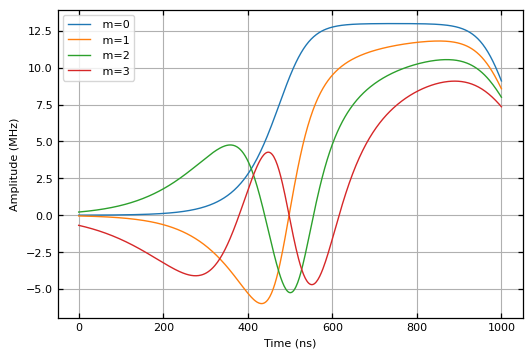

In [22]:
kappa =  0.14*2*np.pi
kappa_ph = 2.5e-3*2*np.pi*2
# t_vals = np.linspace(-500, 500, 501)
t_vals = np.linspace(0, 1000, 501)

def f(t, m, kappa):
    return xi_m(t-(t_vals[-1]-t_vals[0])/2, m, kappa)

def f_prime(t, m, kappa, h=1e-3):
    return (f(t + h, m, kappa) - f(t - h, m, kappa)) / (2 * h)

def compute_g(t_vals, m, kappa, kappa_ph):
    f_vals = f(t_vals, m, kappa_ph)
    f_prime_vals = f_prime(t_vals, m, kappa_ph)
    

    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, t_vals, initial=0)
    
    numerator = f_prime_vals + (kappa * f_vals / 2)
    denominator = np.sqrt(kappa * (1 - integral_vals) - f2_vals)
    
    return numerator / denominator

plt.figure(figsize=(6, 4))
for m in range(4):
    g_vals = compute_g(t_vals, m, kappa, kappa_ph)
    plt.plot(t_vals, np.real(g_vals)/2/np.pi*1e3, label=fr" m={m}")

plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (MHz)")
plt.legend()
plt.grid(True)
plt.show()


## QuTiP simulation

In [23]:
from process_tomography import *
from state_tomography import *
from libys import qtp as ysq
from datataking import search_datadict_miyamura
from qutip import fidelity, Qobj
from analysis import (
    SpatiotemporalAnalysis,demodulate
)

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


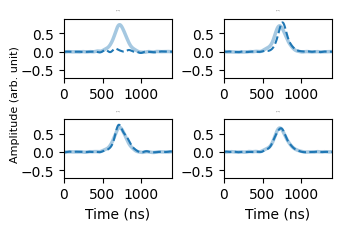

In [5]:
result_dict_tx = dict(
    data_ph0 = dict(target_freq=9.38, date="2025-08-12", acquire_time="124754", duration=1000),
    data_ph1 = dict(target_freq=9.38, date="2025-08-12", acquire_time="124137", duration=1000),
    data_ph2 = dict(target_freq=9.38, date="2025-08-12", acquire_time="124227", duration=1000),
    data_ph3 = dict(target_freq=9.38, date="2025-08-12", acquire_time="125025", duration=1000),
)
result_dict_rx = dict(
    data_ph0 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110853", duration=1000),
    data_ph1 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110223", duration=1000),
    data_ph2 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110313", duration=1000),
    data_ph3 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110403", duration=1000),
)

num_of_ph_amp = 1
num_of_fogi_timing = 51
f_if = (9.5-9.38)*1e9

header = "C:/Users/qipe/Documents/qutip_simulation/codes/data/CDK184/"
ph0_fo0 = "/2025-08-13/2025-08-13T081809_9c21d1b7-j1_JPA_comm_timing"
ph0_fo1 = "/2025-08-12/2025-08-12T145332_addb4dad-j1_JPA_comm_timing"
ph0_fo2 = "/2025-08-12/2025-08-12T223011_78afd813-j1_JPA_comm_timing"
ph0_fo3 = "/2025-08-12/2025-08-12T162316_371a7ee5-j1_JPA_comm_timing"
ph1_fo0 = "/2025-08-12/2025-08-12T205345_fff72f75-j1_JPA_comm_timing"
ph1_fo1 = "/2025-08-12/2025-08-12T214421_11bce74b-j1_JPA_comm_timing"
ph1_fo2 = "/2025-08-12/2025-08-12T183812_10814b2f-j1_JPA_comm_timing"
ph1_fo3 = "/2025-08-12/2025-08-12T192312_59d17cb7-j1_JPA_comm_timing"
ph2_fo0 = "/2025-08-12/2025-08-12T200813_a3f91ff0-j1_JPA_comm_timing"
ph2_fo1 = "/2025-08-13/2025-08-13T010923_b6800336-j1_JPA_comm_timing"
ph2_fo2 = "/2025-08-13/2025-08-13T015414_fa4288d4-j1_JPA_comm_timing"
ph2_fo3 = "/2025-08-13/2025-08-13T023907_3f311ad9-j1_JPA_comm_timing"
ph3_fo0 = "/2025-08-13/2025-08-13T032400_84bc5ae9-j1_JPA_comm_timing"
ph3_fo1 = "/2025-08-13/2025-08-13T040856_cb5ba4f9-j1_JPA_comm_timing"
ph3_fo2 = "/2025-08-13/2025-08-13T045352_12672ec9-j1_JPA_comm_timing"
ph3_fo3 = "/2025-08-13/2025-08-13T053850_5a9232a6-j1_JPA_comm_timing"

acquisition_00 = SpatiotemporalAnalysis(header, ph0_fo0, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_01 = SpatiotemporalAnalysis(header, ph0_fo1, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_02 = SpatiotemporalAnalysis(header, ph0_fo2, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_03 = SpatiotemporalAnalysis(header, ph0_fo3, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_10 = SpatiotemporalAnalysis(header, ph1_fo0, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_11 = SpatiotemporalAnalysis(header, ph1_fo1, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_12 = SpatiotemporalAnalysis(header, ph1_fo2, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_13 = SpatiotemporalAnalysis(header, ph1_fo3, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_20 = SpatiotemporalAnalysis(header, ph2_fo0, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_21 = SpatiotemporalAnalysis(header, ph2_fo1, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_22 = SpatiotemporalAnalysis(header, ph2_fo2, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_23 = SpatiotemporalAnalysis(header, ph2_fo3, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_30 = SpatiotemporalAnalysis(header, ph3_fo0, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_31 = SpatiotemporalAnalysis(header, ph3_fo1, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_32 = SpatiotemporalAnalysis(header, ph3_fo2, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_33 = SpatiotemporalAnalysis(header, ph3_fo3, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

ph_amp = 0
fogi_freq = 17
fig, axs = plt.subplots(2, 2, figsize=(3.2, 2.2) , constrained_layout=True) 
acquisition_00.plot_waveform(ax=axs[0, 0], title="(0, 0)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq, show_title=False, mode=0)
acquisition_01.plot_waveform(ax=axs[0, 1], title="(0, 1)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq, show_title=False, mode=0)
acquisition_02.plot_waveform(ax=axs[1, 0], title="(0, 2)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq, show_title=False, mode=0)
acquisition_03.plot_waveform(ax=axs[1, 1], title="(0, 3)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq, show_title=False, mode=0)
fig.text(-0.02, 0.55, "Amplitude (arb. unit)", va="center", rotation="vertical")
for ax in axs[-1, :]:
    ax.set_xlabel("Time (ns)")
# plt.tight_layout()
plt.show()

In [6]:
acquisitions = [[None for _ in range(4)] for _ in range(4)]

acquisitions[0][0] = acquisition_00
acquisitions[0][1] = acquisition_01
acquisitions[0][2] = acquisition_02
acquisitions[0][3] = acquisition_03

acquisitions[1][0] = acquisition_10
acquisitions[1][1] = acquisition_11
acquisitions[1][2] = acquisition_12
acquisitions[1][3] = acquisition_13

acquisitions[2][0] = acquisition_20
acquisitions[2][1] = acquisition_21
acquisitions[2][2] = acquisition_22
acquisitions[2][3] = acquisition_23

acquisitions[3][0] = acquisition_30
acquisitions[3][1] = acquisition_31
acquisitions[3][2] = acquisition_32
acquisitions[3][3] = acquisition_33

### photon emission

In [7]:
n_cutoff_q = 3
n_cutoff_r = 2
n_cutoff_vc = 3

b = qt.tensor(qt.destroy(n_cutoff_q), qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
a = qt.tensor(qt.qeye(n_cutoff_q), qt.destroy(n_cutoff_r), qt.qeye(n_cutoff_vc))
vc = qt.tensor(qt.qeye(n_cutoff_q), qt.qeye(n_cutoff_r), qt.destroy(n_cutoff_vc))

zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,1]=1
gedecayop=Qobj(zeromatrixxtmp)
etog = qt.tensor(gedecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,2]=1
efdecayop=Qobj(zeromatrixxtmp)
ftoe = qt.tensor(efdecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,0]=-1
zeromatrixxtmp[1,1]=1
gedechoop=Qobj(zeromatrixxtmp)
dechoge = qt.tensor(gedechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,1]=-1
zeromatrixxtmp[2,2]=1
efdechoop=Qobj(zeromatrixxtmp)
dechoef = qt.tensor(efdechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))

g0 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
f0 = qt.tensor(qt.basis(n_cutoff_q, 2), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
g1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 1), qt.basis(n_cutoff_vc, 0))
e0 = qt.tensor(qt.basis(n_cutoff_q, 1), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
vc1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1))

alpha = -0.356 * 2 * np.pi
chi = -0.0076 * 2 * np.pi
eta = 0.67
kappa_r = 0.14 * 2 * np.pi
K = 0 * 2 * np.pi

H_fogi = (
    -alpha / 2 * b.dag()*b + alpha * b.dag()*b.dag()*b*b / 2
    +K * a.dag()*a.dag()*a*a / 2 + 2*chi*a.dag()*a*b.dag()*b
)

H_d = -a.dag()*b*b/np.sqrt(2)
H_c = 1j * (np.sqrt(kappa_r)/2) * vc.dag()*a

T1ge=29*1e3
T1ef=22*1e3
T2ge=5*1e3
T2ef=5*1e3
Tphige=1/((1/T2ge-1/T1ge/2)/2)
Tphief=1/((1/T2ef-1/T1ef/2)/2)

e_ops = []
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=1000, max_step=0.1, store_states=True)

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


In [24]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

T = 500 
N = 251
# tgrid = np.linspace(-T, T, N)
tgrid = np.linspace(0, 2*T, N)
dt = tgrid[1] - tgrid[0]
kappa_ph = 2.5e-3 * 2 * np.pi * 2

_eps = 1e-14

g_interps = []
g_interps_rvs = []

for m in range(4): 
    f_vals = f(tgrid, m, kappa_ph)
    f_prime_vals = f_prime(tgrid, m, kappa_ph) 
    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, tgrid, initial=0)

    # numerator = f_prime_vals + (kappa_r * f_vals / 2)
    # denominator = np.sqrt(kappa_r * (1.0 - integral_vals) - f2_vals)
    numerator =  (kappa_r * f_vals / 2)
    denominator = np.sqrt(kappa_r * (1.0 - integral_vals))
    g_vals = numerator / denominator
    g_interp = interp1d(tgrid, np.real(g_vals), kind='cubic', fill_value='extrapolate')
    g_interps.append(g_interp)

    g_interp_rvs = interp1d(tgrid, np.real(g_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    g_interps_rvs.append(g_interp_rvs)
    
g_u_interps = []
for m in range(4):
    ut_vals = xi_m(tgrid-(t_vals[-1]-t_vals[0])/2, m, kappa_ph) #` fix me
    cumint = cumulative_trapezoid(np.abs(ut_vals)**2, tgrid, initial=0)
    eps = 1e-14
    denom = np.sqrt(1.0 - cumint + eps)
    g_vals = np.conjugate(ut_vals) / denom
    g_interp = interp1d(tgrid, g_vals, kind='cubic', fill_value='extrapolate')
    g_u_interps.append(g_interp)
    
def g_u(t, args):
    m = int(args["input_num"])
    t_local = float(t)- float(args["center"])
    return float(args["g_u_interps"][m](t_local))

def g_u_conj(t, args):
    return np.conjugate(g_u(t, args))


def g_time(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps"][m](t_local))

def g_time_conj(t, args):
    return np.conjugate(g_time(t, args))

def g_time_rvs(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps_rvs"][m](t_local))

def g_time_conj_rvs(t, args):
    return np.conjugate(g_time_rvs(t, args))


In [9]:
base_args = {
    "center": 0.0,
    "fogi_mode": 2,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 0,
}
results = {} 

for m in range(4):
    args_m = base_args.copy()
    args_m["fogi_mode"] = m

    H_m = [
        H_fogi,
        [H_d, g_time], [H_d.dag(), g_time_conj],
    ]
    psi0_m = (g0 + f0).unit()


    def total_c_op(t, args):
        c_op = np.sqrt(kappa_r) * a
        return c_op

    c_ops_m = [
        total_c_op,
        np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
        np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
    ]

    result_m = qt.mesolve(
        H_m, psi0_m, tgrid-tgrid[0], c_ops_m, e_ops=e_ops,
        args=args_m, options=options, progress_bar=True
    )

    results[m] = result_m
    print(f"mode {m} finished")
# Extract states

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


10.0%. Run time:   1.53s. Est. time left: 00:00:00:13
20.0%. Run time:   3.48s. Est. time left: 00:00:00:13
30.0%. Run time:   6.01s. Est. time left: 00:00:00:14
40.0%. Run time:   7.85s. Est. time left: 00:00:00:11
50.0%. Run time:   9.82s. Est. time left: 00:00:00:09
60.0%. Run time:  11.85s. Est. time left: 00:00:00:07
70.0%. Run time:  14.08s. Est. time left: 00:00:00:06
80.0%. Run time:  16.21s. Est. time left: 00:00:00:04
90.0%. Run time:  18.19s. Est. time left: 00:00:00:02
100.0%. Run time:  20.21s. Est. time left: 00:00:00:00
Total run time:  20.21s
mode 0 finished
10.0%. Run time:   1.07s. Est. time left: 00:00:00:09
20.0%. Run time:   1.50s. Est. time left: 00:00:00:06
30.0%. Run time:   1.92s. Est. time left: 00:00:00:04
40.0%. Run time:   2.36s. Est. time left: 00:00:00:03
50.0%. Run time:   2.81s. Est. time left: 00:00:00:02
60.0%. Run time:   3.23s. Est. time left: 00:00:00:02
70.0%. Run time:   3.62s. Est. time left: 00:00:00:01
80.0%. Run time:   4.08s. Est. time left:

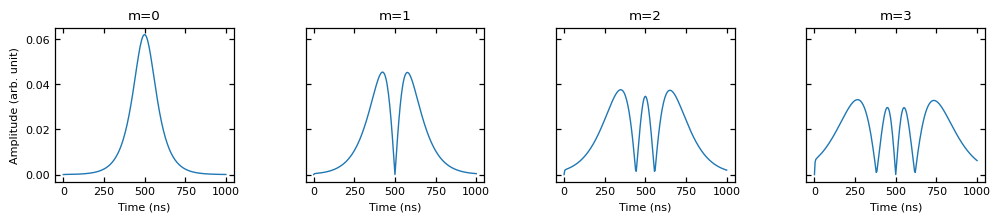

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2), sharey=True)
plt.subplots_adjust(wspace=0.4)

# Input operators
for i in range(4):
    states = results[i].states
    vcdvc_s = qt.expect(vc.dag() * vc, states)
    ada_s = qt.expect(a.dag() * a, states)
    vcda_s = qt.expect(vc.dag() * a, states)
    advc_s = qt.expect(a.dag() * vc, states)
    gu_values = np.array([g_u(t, base_args) for t in tgrid])
    LdL = (
        # gu_values * np.conjugate(gu_values) * vcdvc_s
        + kappa_r * ada_s
        # + np.sqrt(kappa_r) * (gu_values * vcda_s + np.conjugate(gu_values) * advc_s)
    )
    axes[i].plot(tgrid, np.sqrt(LdL), label="photon waveform")
    axes[i].set_title(f"m={i}")
    axes[i].set_xlabel(r"Time (ns)")
    if i == 0:
        axes[i].set_ylabel("Amplitude (arb. unit)")
plt.show()

In [ ]:
opts = Options(store_states=True, store_final_state=False, nsteps=1000, progress_bar=True)

options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=1000, max_step=0.1, store_states=True)
base_args = {
    "center": 0.0,
    "fogi_mode": 2,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 0,
}
results_output = {} 
def total_c_op(t, args):
    c_op = np.sqrt(kappa_r) * a
    return c_op

def L_func(t, args):
    return np.sqrt(kappa_r) * a

def L_dag_func(t, args):
    return np.sqrt(kappa_r) * a.dag()

for m in range(4):
    args_m = base_args.copy()
    args_m["fogi_mode"] = m

    H_m = [
        H_fogi,
        [H_d, g_time], [H_d.dag(), g_time_conj],
        ]
    
    c_ops_m = [
        total_c_op,
        np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
        np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
    ]
    psi0_m = (g0 +1j* f0).unit()
    G1 = qt.correlation_2op_2t(
        H_m,     
        psi0_m,
        tgrid-tgrid[0],
        tgrid-tgrid[0],
        c_ops_m,
        L_dag_func,
        L_func,
        args=args_m,
        options=opts
    )

    results_output[m] = G1
    print(f"mode {m} finished")

import h5py

# with h5py.File("results_output_emi.h5", "w") as f:
#     for m, G in results_output.items():
#         f.create_dataset(f"m{m}", data=G)

10.3%. Run time:  15.82s. Est. time left: 00:00:02:17
20.2%. Run time:  27.83s. Est. time left: 00:00:01:49
30.2%. Run time:  43.50s. Est. time left: 00:00:01:40
40.1%. Run time:  56.06s. Est. time left: 00:00:01:23
50.0%. Run time:  80.01s. Est. time left: 00:00:01:20
60.3%. Run time: 113.43s. Est. time left: 00:00:01:14
70.2%. Run time: 145.63s. Est. time left: 00:00:01:01
80.2%. Run time: 180.95s. Est. time left: 00:00:00:44
90.1%. Run time: 246.34s. Est. time left: 00:00:00:27
100.0%. Run time: 326.48s. Est. time left: 00:00:00:00
Total run time: 326.48s
mode 0 finished
10.3%. Run time:  10.59s. Est. time left: 00:00:01:32
20.2%. Run time:  21.60s. Est. time left: 00:00:01:25
30.2%. Run time:  31.77s. Est. time left: 00:00:01:13
40.1%. Run time:  41.16s. Est. time left: 00:00:01:01
50.0%. Run time:  51.05s. Est. time left: 00:00:00:51
60.3%. Run time:  62.51s. Est. time left: 00:00:00:41
70.2%. Run time:  76.80s. Est. time left: 00:00:00:32
80.2%. Run time:  96.20s. Est. time left:

In [9]:
import h5py
results_output_emi = {}
with h5py.File("results_output_emi.h5", "r") as f:
    for m_key in f.keys():
        m = int(m_key[1:])
        results_output_emi[m] = f[f"{m_key}"][:]

fig, axes = plt.subplots(3, 4, figsize=(8, 6), sharey='row')
plt.subplots_adjust(wspace=0.4, hspace=0.6, left=0.05, right=0.90, top=0.95, bottom=0.1)

principal_modes = []

Nt = len(tgrid)
dt = tgrid[1] - tgrid[0]

vmin = min(np.min(G1.real) for G1 in results_output_emi.values())

for i in range(4):
    G1 = results_output_emi[i]
    G1_new = np.zeros((Nt, Nt),  dtype=complex)

    for idx_b, t_b in enumerate(tgrid):
        for idx_a, t_a in enumerate(tgrid):
            tau_idx = int(idx_a - idx_b)
            if 0 <= tau_idx < Nt:
                G1_new[idx_a, idx_b] = G1[idx_b, tau_idx]
            else:
                G1_new[idx_a, idx_b] = np.conjugate(G1_new[idx_b, idx_a])

    eigs, eigvecs = np.linalg.eigh(G1_new)
    sort_idx = np.argsort(eigs)[::-1]
    eigvecs = eigvecs[:, sort_idx]
    eigs = eigs[sort_idx]
    eigs_frac = eigs / np.sum(eigs)

    im = axes[0, i].imshow(
        G1_new.real,
        extent=[tgrid[0], tgrid[-1], tgrid[0], tgrid[-1]],
        cmap="RdBu_r",
        origin="lower",
        aspect="auto",
        vmin=vmin,
        vmax=-vmin
    )
    axes[0, i].set_title(f"m={i}")
    axes[0, i].set_xlabel("t₂ (ns)")
    if i == 0:
        axes[0, i].set_ylabel("t₁ (ns)")

    diag_vals = np.real(np.diag(G1_new))
    axes[1, i].plot(tgrid, diag_vals, color='tab:blue')
    axes[1, i].set_xlabel("t (ns)")
    if i == 0:
        axes[1, i].set_ylabel(r"$G^{(1)}(t,t)$")

    lines = []
    labels = []
    for k in range(min(2, len(eigs))):
        v = eigvecs[:, k]
        v_norm = v / np.sqrt(np.trapz(np.abs(v)**2, tgrid))
        line, = axes[2, i].plot(tgrid, np.real(v_norm))
        lines.append(line)
        labels.append(f"$v_{{{k+1}}}(t)$, $n_{{{k+1}}}$={eigs_frac[k]:.2f}")

    axes[2, i].legend(handles=lines, labels=labels, fontsize=8,
                      loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=1)
    axes[2, i].set_xlabel("t (ns)")
    if i == 0:
        axes[2, i].set_ylabel("Mode amplitude")

    principal_modes.append(eigvecs[:, 0] / np.sqrt(np.trapz(np.abs(eigvecs[:, 0])**2, tgrid)))

cbar_ax = fig.add_axes([0.92, 0.7, 0.01, 0.25])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"$g^{(1)}(t_1, t_2)$")

plt.show()

N_modes = len(principal_modes)
overlap_matrix = np.zeros((N_modes, N_modes), dtype=float)

for i in range(N_modes):
    for j in range(N_modes):
        overlap_matrix[i, j] = np.abs(np.trapz(np.conj(principal_modes[i]) * principal_modes[j], tgrid))

fig2, ax2 = plt.subplots(figsize=(2.5, 2.))
im2 = ax2.imshow(overlap_matrix**2, origin='lower', cmap='viridis', vmin=0, vmax=1)
cbar2 = fig2.colorbar(im2)
cbar2.set_label(r"$|\langle v_1^\mathrm{mode i} | v_1^\mathrm{mode j} \rangle|^2$")
ax2.set_xlabel("Mode index")
ax2.set_ylabel("Mode index")
plt.show()


C:\Users\qipe\AppData\Local\Temp\ipykernel_2752\388256440.py:60: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  v_norm = v / np.sqrt(np.trapz(np.abs(v)**2, tgrid))
C:\Users\qipe\AppData\Local\Temp\ipykernel_2752\388256440.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  principal_modes.append(eigvecs[:, 0] / np.sqrt(np.trapz(np.abs(eigvecs[:, 0])**2, tgrid)))


KeyboardInterrupt: 

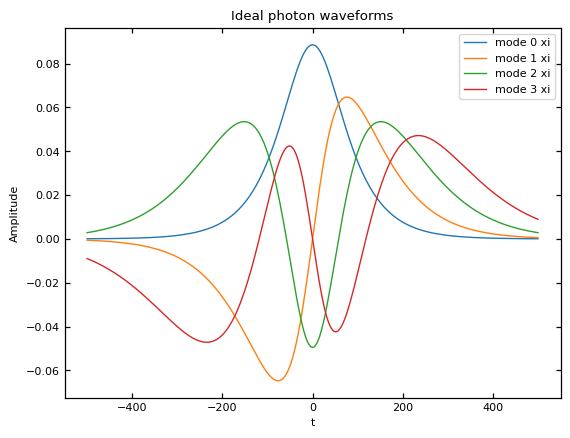

C:\Users\qipe\AppData\Local\Temp\ipykernel_35616\2172859359.py:48: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  v_norm = v / np.sqrt(np.trapz(np.abs(v)**2, tgrid))
C:\Users\qipe\AppData\Local\Temp\ipykernel_35616\2172859359.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  v_principal = eigvecs[:, 0] / np.sqrt(np.trapz(np.abs(eigvecs[:, 0])**2, tgrid))


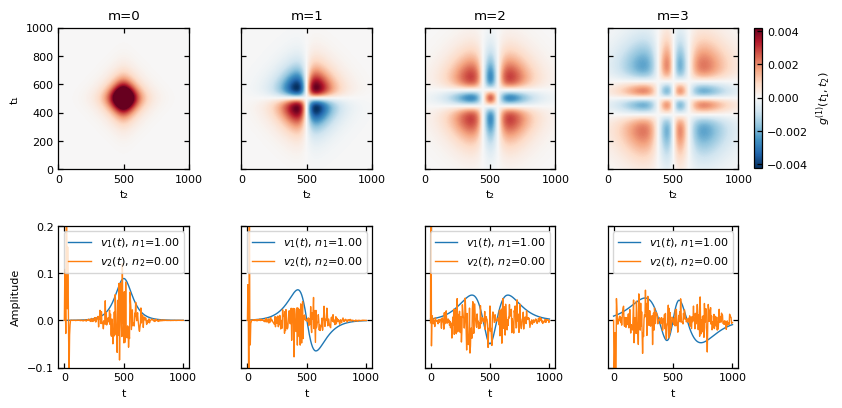

C:\Users\qipe\AppData\Local\Temp\ipykernel_35616\2172859359.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  overlap_matrix[i, j] = np.abs(np.trapz(np.conj(principal_modes_ideal[i]) * principal_modes_ideal[j], tgrid))


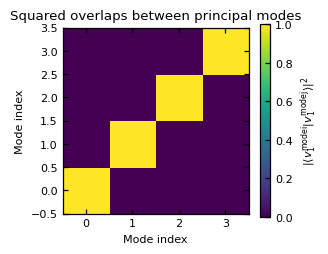

In [11]:
# autocorrelation of ideal waveforms
results_output_ideal = {}
alpha_phase = 1.0 

for m in range(N_modes):
    xi_vals = xi_m(tgrid-(tgrid[-1]-tgrid[0])/2, m, kappa_ph)

    xi_vals_mod = xi_vals
    G1_ideal = np.outer(np.conj(xi_vals_mod), xi_vals)
    results_output_ideal[m] = G1_ideal

    plt.plot(tgrid-(tgrid[-1]-tgrid[0])/2, xi_vals, label=f"mode {m} xi")
plt.xlabel("t")
plt.ylabel("Amplitude")
plt.title("Ideal photon waveforms")
plt.legend()
plt.show()

fig, axes = plt.subplots(2, N_modes, figsize=(8, 4), sharey='row')
plt.subplots_adjust(wspace=0.4, hspace=0.4, left=0.05, right=0.90, top=0.95, bottom=0.1)
vmin = min(np.min(G1.real) for G1 in results_output_ideal.values())
principal_modes_ideal = []
for i in range(N_modes):
    G1 = results_output_ideal[i]

    eigs, eigvecs = np.linalg.eigh(G1)
    sort_idx = np.argsort(eigs)[::-1]
    eigs = eigs[sort_idx]
    eigvecs = eigvecs[:, sort_idx]
    eigs_frac = eigs / np.sum(eigs)

    im = axes[0, i].imshow(
        G1.real,
        extent=[tgrid[0], tgrid[-1], tgrid[0], tgrid[-1]],
        cmap="RdBu_r",
        origin="lower",
        aspect="auto",
        vmin=vmin,
        vmax=-vmin
    )
    axes[0, i].set_title(f"m={i}")
    axes[0, i].set_xlabel("t₂")
    if i == 0:
        axes[0, i].set_ylabel("t₁")

    for k in range(min(2, len(eigs))):
        v = eigvecs[:, k]
        v_norm = v / np.sqrt(np.trapz(np.abs(v)**2, tgrid))
        label = fr"$v_{{{k+1}}}(t)$, $n_{{{k+1}}}$={eigs_frac[k]:.2f}"
        axes[1, i].plot(tgrid, np.real(v_norm), label=label)

    v_principal = eigvecs[:, 0] / np.sqrt(np.trapz(np.abs(eigvecs[:, 0])**2, tgrid))
    principal_modes_ideal.append(v_principal)

    axes[1, i].legend(fontsize=8)
    axes[1, i].set_xlabel("t")
    axes[1, i].set_ylim(-0.1, 0.2)
    if i == 0:
        axes[1, i].set_ylabel("Amplitude")
        
cbar_ax = fig.add_axes([0.92, 0.6, 0.01, 0.35])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"$g^{(1)}(t_1, t_2)$")
plt.show()

overlap_matrix = np.zeros((N_modes, N_modes), dtype=float)
for i in range(N_modes):
    for j in range(N_modes):
        overlap_matrix[i, j] = np.abs(np.trapz(np.conj(principal_modes_ideal[i]) * principal_modes_ideal[j], tgrid))

fig2, ax2 = plt.subplots(figsize=(3, 2.5))
im2 = ax2.imshow(overlap_matrix**2, origin='lower', cmap='viridis', vmin=0, vmax=1)
cbar2 = fig2.colorbar(im2)
cbar2.set_label(r"$|\langle v_1^\mathrm{mode i} | v_1^\mathrm{mode j} \rangle|^2$")

ax2.set_xlabel("Mode index")
ax2.set_ylabel("Mode index")
ax2.set_title("Squared overlaps between principal modes")
plt.show()


### photon absorption

In [12]:
base_args = {
    "center": 0,
    "fogi_mode": 0,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 1,
}
results = {} 

for m in range(4):
    args_mn = base_args.copy()
    args_mn["input_num"] = m

    for n in range(4):
        args_mn["fogi_mode"] = n
        H_m = [
            H_fogi,
            [H_c, g_u], [H_c.dag(), g_u_conj],
            [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
        ]
        psi0_m = vc1

        def total_c_op(t, args):
            c_op = np.conjugate(g_u(t, args)) * vc + np.sqrt(kappa_r) * a
            return c_op

        c_ops_mn = [
            total_c_op,
            np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
            np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
        ]

        result_mn = qt.mesolve(
            H_m, psi0_m, tgrid-tgrid[0], c_ops_mn, e_ops=e_ops,
            args=args_mn, options=options, progress_bar=True
        )

        results[(m, n)] = result_mn 
    print(f"mode {m} finished")


c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


10.0%. Run time:   1.42s. Est. time left: 00:00:00:12
20.0%. Run time:   2.83s. Est. time left: 00:00:00:11
30.0%. Run time:   4.42s. Est. time left: 00:00:00:10
40.0%. Run time:   6.05s. Est. time left: 00:00:00:09
50.0%. Run time:   7.13s. Est. time left: 00:00:00:07
60.0%. Run time:   8.70s. Est. time left: 00:00:00:05
70.0%. Run time:  10.35s. Est. time left: 00:00:00:04
80.0%. Run time:  12.43s. Est. time left: 00:00:00:03
90.0%. Run time:  13.62s. Est. time left: 00:00:00:01
100.0%. Run time:  14.62s. Est. time left: 00:00:00:00
Total run time:  14.62s
10.0%. Run time:   1.00s. Est. time left: 00:00:00:08
20.0%. Run time:   2.34s. Est. time left: 00:00:00:09
30.0%. Run time:   3.67s. Est. time left: 00:00:00:08
40.0%. Run time:   5.29s. Est. time left: 00:00:00:07
50.0%. Run time:   6.72s. Est. time left: 00:00:00:06
60.0%. Run time:   7.96s. Est. time left: 00:00:00:05
70.0%. Run time:   9.59s. Est. time left: 00:00:00:04
80.0%. Run time:  11.17s. Est. time left: 00:00:00:02
90.

In [10]:
from scipy import interpolate, optimize
from scipy.ndimage import shift as nd_shift

def fit_waveform(time, waveform_exp, waveform_sim, x0=[1.0, 0.0]):

    def func(params):
        scale, shift = params
        sim_shifted = roll_with_interpolation(waveform_sim, shift=-shift)
        return scale * sim_shifted

    def cost_func(params):
        return np.linalg.norm(np.abs(func(params)) - np.abs(waveform_exp))

    best_x = optimize.minimize(cost_func, x0, method='Nelder-Mead').x
    print("best_x:", best_x)

    fitted = func(best_x)
    return fitted, best_x

def roll_with_interpolation(array, shift):
    return nd_shift(array, shift=shift, mode='constant', cval=0.0)


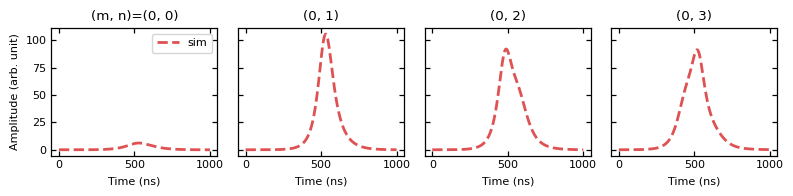

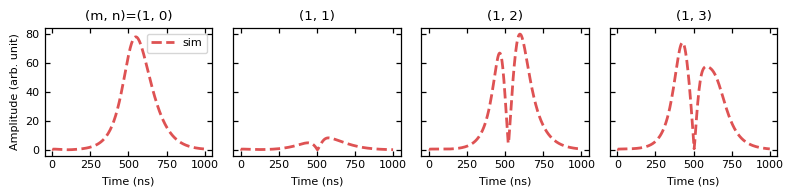

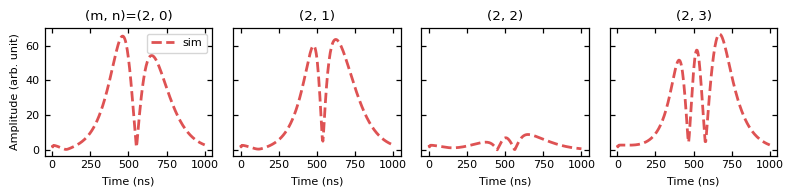

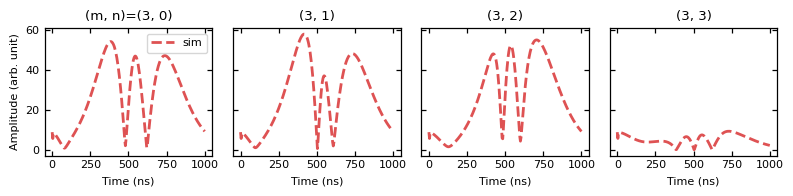

In [33]:

for m in range(4):    
    fig, axes = plt.subplots(1, 4, figsize=(8, 2), sharey=True)
    plt.subplots_adjust(wspace=0.4)

    for n in range(4):
        states = results[(m, n)].states
        vcdvc_s = qt.expect(vc.dag() * vc, states)
        ada_s = qt.expect(a.dag() * a, states)
        vcda_s = qt.expect(vc.dag() * a, states)
        advc_s = qt.expect(a.dag() * vc, states)
        args = {
            "center": 0,
            "fogi_mode": n,
            "g_interps": g_interps,
            "g_interps_rvs": g_interps_rvs,
            "g_u_interps": g_u_interps,
            "input_num": m,
            "input": 0,
        }  

        gu_values = np.array([g_u(t, args) for t in tgrid])
        LdL = (
            gu_values * np.conjugate(gu_values) * vcdvc_s
            + kappa_r * ada_s
            + np.sqrt(kappa_r) * (gu_values * vcda_s + np.conjugate(gu_values) * advc_s)
        )
        # abs_exp = acquisitions[m][n].get_results()["y_absorbed_signals"][ph_amp][fogi_freq][100:-149]
        # fitted_dummy, best_x = fit_waveform(tgrid, np.abs(abs_exp), np.sqrt(LdL), x0=[1.0, 10.0])
        # scale, shift_val = best_x
        # def apply_fit(waveform, scale, shift_val, time):
        #     waveform_resampled = np.interp(time, np.linspace(time[0], time[-1], len(waveform)), waveform)
        #     dt = time[1] - time[0]
        #     shift_idx = -shift_val / dt 
        #     return scale * nd_shift(waveform_resampled, shift=shift_idx, mode='constant', cval=0.0)
        
        # fitted_abs_sim = apply_fit(np.sqrt(LdL), scale, shift_val, tgrid)
            
        # axes[n].plot(tgrid, np.abs(abs_exp)*1e3, lw=4, alpha=0.6, color="tab:blue", label="exp")
        # axes[n].plot(tgrid, np.abs(fitted_abs_sim)*1e3, lw=2, alpha=0.8, linestyle="--", color="tab:red", label="sim")
        
        axes[n].plot(tgrid, np.sqrt(LdL)*1e3, lw=2, alpha=0.8, linestyle="--", color="tab:red", label="sim")
        axes[n].set_xlabel(r"Time (ns)")
        if n == 0:
            axes[n].legend()
            axes[n].set_ylabel("Amplitude (arb. unit)")
            axes[n].set_title(f"(m, n)=({m}, {n})")
        else:
            axes[n].set_title(f"({m}, {n})")
    plt.tight_layout()
    plt.show()

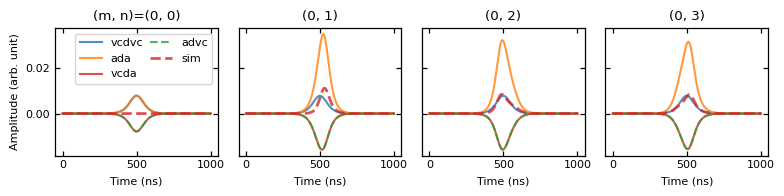

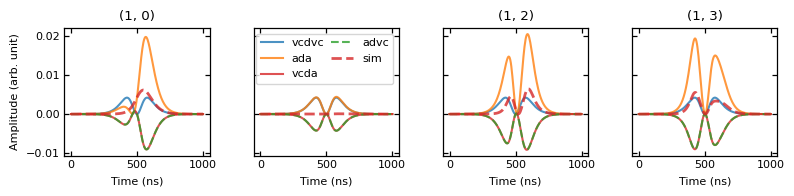

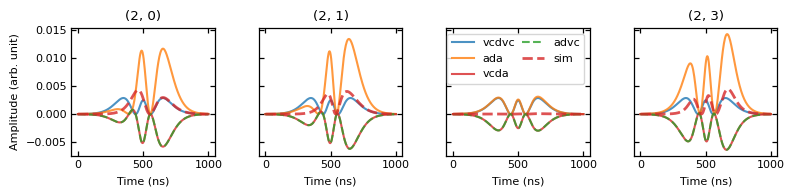

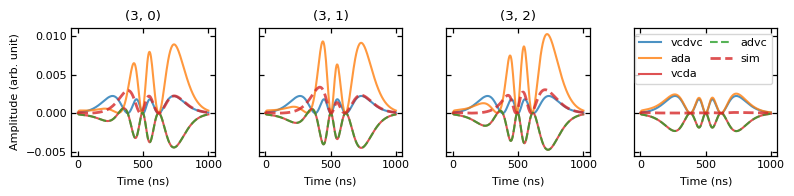

In [13]:

for m in range(4):    
    fig, axes = plt.subplots(1, 4, figsize=(8, 2), sharey=True)
    plt.subplots_adjust(wspace=0.4)

    for n in range(4):
        states = results[(m, n)].states
        vcdvc_s = qt.expect(vc.dag() * vc, states)
        ada_s = qt.expect(a.dag() * a, states)
        vcda_s = qt.expect(vc.dag() * a, states)
        advc_s = qt.expect(a.dag() * vc, states)
        args = {
            "center": 0,
            "fogi_mode": n,
            "g_interps": g_interps,
            "g_interps_rvs": g_interps_rvs,
            "g_u_interps": g_u_interps,
            "input_num": m,
            "input": 0,
        }  

        gu_values = np.array([g_u(t, args) for t in tgrid])
        LdL = (
            gu_values * np.conjugate(gu_values) * vcdvc_s
            + kappa_r * ada_s
            + np.sqrt(kappa_r) * (gu_values * vcda_s + np.conjugate(gu_values) * advc_s)
        )
        vcdvc = (
            gu_values * np.conjugate(gu_values) * vcdvc_s
        )
        ada = (
            + kappa_r * ada_s
        )
        vcda = (
            + np.sqrt(kappa_r) * (gu_values * vcda_s)
        )
        advc = (
            + np.sqrt(kappa_r) * (np.conjugate(gu_values) * advc_s)
        )
        # abs_exp = acquisitions[m][n].get_results()["y_absorbed_signals"][ph_amp][fogi_freq][100:-149]
        # fitted_dummy, best_x = fit_waveform(tgrid, np.abs(abs_exp), np.sqrt(LdL), x0=[1.0, 10.0])
        # scale, shift_val = best_x
        # def apply_fit(waveform, scale, shift_val, time):
        #     waveform_resampled = np.interp(time, np.linspace(time[0], time[-1], len(waveform)), waveform)
        #     dt = time[1] - time[0]
        #     shift_idx = -shift_val / dt 
        #     return scale * nd_shift(waveform_resampled, shift=shift_idx, mode='constant', cval=0.0)
        
        # fitted_abs_sim = apply_fit(np.sqrt(LdL), scale, shift_val, tgrid)
            
        # axes[n].plot(tgrid, np.abs(abs_exp)*1e3, lw=4, alpha=0.6, color="tab:blue", label="exp")
        # axes[n].plot(tgrid, np.abs(fitted_abs_sim)*1e3, lw=2, alpha=0.8, linestyle="--", color="tab:red", label="sim")
        
        axes[n].plot(tgrid, vcdvc, lw=1.5, alpha=0.8, color="tab:blue", label="vcdvc")
        axes[n].plot(tgrid, ada, lw=1.5, alpha=0.8, color="tab:orange", label="ada")
        axes[n].plot(tgrid, vcda, lw=1.5, alpha=0.8, color="tab:red", label="vcda")
        axes[n].plot(tgrid, advc, lw=1.5, alpha=0.8, linestyle="--", color="tab:green", label="advc")
        axes[n].plot(tgrid, LdL, lw=2, alpha=0.8, linestyle="--", color="tab:red", label="sim")
        axes[n].set_xlabel(r"Time (ns)")
        if n == 0:
            axes[n].set_ylabel("Amplitude (arb. unit)")
            axes[n].set_title(f"(m, n)=({m}, {n})")
        if n==m:
            axes[n].legend(loc='upper right', ncol=2, columnspacing=0.6)
        else:
            axes[n].set_title(f"({m}, {n})")
    plt.tight_layout()
    plt.show()

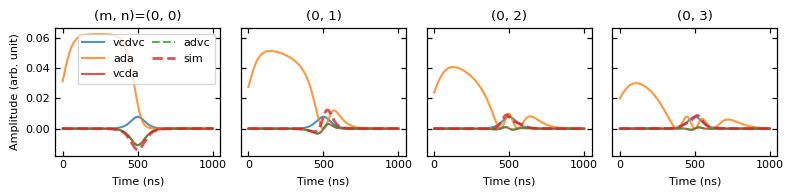

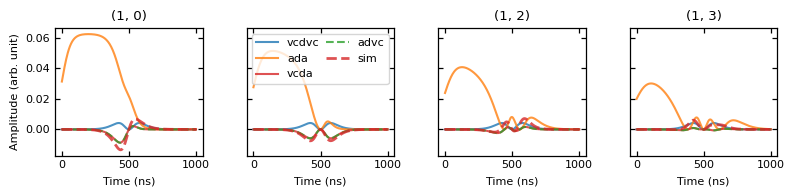

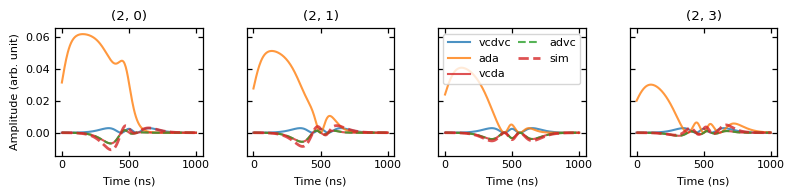

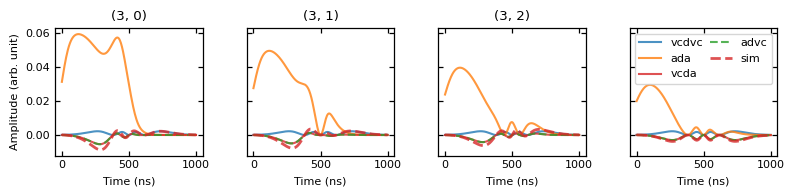

In [38]:
for m in range(4):    
    fig, axes = plt.subplots(1, 4, figsize=(8, 2), sharey=True)
    plt.subplots_adjust(wspace=0.4)

    for n in range(4):
        states = results[(m, n)].states
        vcdvc_s = qt.expect(vc.dag() * vc, states)
        bbbdbd_s = qt.expect(b*b*b.dag()*b.dag(), states)
        vcbdbd_s = qt.expect(1j*vc*b.dag()*b.dag(), states)
        vcdbb_s = qt.expect(1j*vc.dag() * b*b, states)
        args = {
            "center": 0,
            "fogi_mode": n,
            "g_interps": g_interps,
            "g_interps_rvs": g_interps_rvs,
            "g_u_interps": g_u_interps,
            "input_num": m,
            "input": 0,
        }  

        gu_values = np.array([g_u(t, args) for t in tgrid])
        gu_tr_values = np.array([g_time_rvs(t, args) for t in tgrid])/(np.sqrt(kappa_r)/2)
        # plt.plot(gu_values)
        # plt.plot(gu_tr_values)
        # plt.show()
        LdL = (
            gu_values * np.conjugate(gu_values) * vcdvc_s
            # +  gu_tr_values * np.conjugate(gu_tr_values) * bbbdbd_s
            + (np.conjugate(gu_values)* gu_tr_values * vcbdbd_s - gu_values*np.conjugate(gu_tr_values) * vcdbb_s)
        )
        vcdvc = (
            gu_values * np.conjugate(gu_values) * vcdvc_s
        )
        ada = (
            + gu_tr_values * np.conjugate(gu_tr_values) * bbbdbd_s
        )
        vcda = (
            + np.conjugate(gu_values)* gu_tr_values * vcbdbd_s
        )
        advc = (
            - gu_values*np.conjugate(gu_tr_values) * vcdbb_s
        )
        # abs_exp = acquisitions[m][n].get_results()["y_absorbed_signals"][ph_amp][fogi_freq][100:-149]
        # fitted_dummy, best_x = fit_waveform(tgrid, np.abs(abs_exp), np.sqrt(LdL), x0=[1.0, 10.0])
        # scale, shift_val = best_x
        # def apply_fit(waveform, scale, shift_val, time):
        #     waveform_resampled = np.interp(time, np.linspace(time[0], time[-1], len(waveform)), waveform)
        #     dt = time[1] - time[0]
        #     shift_idx = -shift_val / dt 
        #     return scale * nd_shift(waveform_resampled, shift=shift_idx, mode='constant', cval=0.0)
        
        # fitted_abs_sim = apply_fit(np.sqrt(LdL), scale, shift_val, tgrid)
            
        # axes[n].plot(tgrid, np.abs(abs_exp)*1e3, lw=4, alpha=0.6, color="tab:blue", label="exp")
        # axes[n].plot(tgrid, np.abs(fitted_abs_sim)*1e3, lw=2, alpha=0.8, linestyle="--", color="tab:red", label="sim")
        
        axes[n].plot(tgrid, vcdvc, lw=1.5, alpha=0.8, color="tab:blue", label="vcdvc")
        axes[n].plot(tgrid, ada, lw=1.5, alpha=0.8, color="tab:orange", label="ada")
        axes[n].plot(tgrid, vcda, lw=1.5, alpha=0.8, color="tab:red", label="vcda")
        axes[n].plot(tgrid, advc, lw=1.5, alpha=0.8, linestyle="--", color="tab:green", label="advc")
        axes[n].plot(tgrid, LdL, lw=2, alpha=0.8, linestyle="--", color="tab:red", label="sim")
        axes[n].set_xlabel(r"Time (ns)")
        if n == 0:
            axes[n].set_ylabel("Amplitude (arb. unit)")
            axes[n].set_title(f"(m, n)=({m}, {n})")
        if n==m:
            axes[n].legend(loc='upper right', ncol=2, columnspacing=0.6)
        else:
            axes[n].set_title(f"({m}, {n})")
    plt.tight_layout()
    plt.show()

In [ ]:
###
opts = Options(store_states=True, store_final_state=False, nsteps=5000, progress_bar=True)
results_output_abs = {} 
eta = 1 # photon loss, 0122 added
eff = 1 # reflection efficiency, 0122 added

def sqrt_kappa_constant(t, args):
    return np.sqrt(kappa_r)

for m in range(4):
    args_mn = base_args.copy()
    args_mn["input_num"] = m

    def g_u_func(t, args):
        t_local = float(t)
        return g_u_interps[m](t_local)

    def g_u_conj_func(t, args):
        return np.conjugate(g_u_func(t, args))

    def L_func_abs(t, args=args_mn):
        return g_u_conj_func(t, args) * vc + sqrt_kappa_constant(t, args) * a

    def L_dag_func_abs(t, args=args_mn):
        return g_u_func(t, args) * vc.dag() + sqrt_kappa_constant(t, args) * a.dag()

    for n in range(4):
        args_mn["fogi_mode"] = n
        H_m = [
            H_fogi,
            [H_c*np.sqrt(eta)*np.sqrt(eff), g_u], [H_c.dag()*np.sqrt(eta)*np.sqrt(eff), g_u_conj],
            [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
        ]
        psi0_m = vc1

        def total_c_op(t, args):
            c_op = np.conjugate(g_u(t, args)) * vc + np.sqrt(kappa_r) * a
            return c_op

        c_ops_mn = [
            total_c_op,
            np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
            np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
        ]
  
        G1_mn = qt.correlation_2op_2t(
            H_m,     
            psi0_m,
            tgrid-tgrid[0],
            tgrid-tgrid[0],
            c_ops_mn,
            L_dag_func_abs,
            L_func_abs,
            args=args_mn,
            options=opts
        )

        results_output_abs[(m, n)] = G1_mn
    print(f"mode {m} finished")

import h5py

with h5py.File("results_output_abs_0203.h5", "w") as f:
    for (m, n), G in results_output_abs.items():
        f.create_dataset(f"m{m}/n{n}", data=G)

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


10.3%. Run time:  22.21s. Est. time left: 00:00:03:13
20.2%. Run time:  36.95s. Est. time left: 00:00:02:25
30.2%. Run time:  64.15s. Est. time left: 00:00:02:28
40.1%. Run time:  78.39s. Est. time left: 00:00:01:57
50.0%. Run time:  96.72s. Est. time left: 00:00:01:36
60.3%. Run time: 140.76s. Est. time left: 00:00:01:32
70.2%. Run time: 266.37s. Est. time left: 00:00:01:52
80.2%. Run time: 630.66s. Est. time left: 00:00:02:36
90.1%. Run time: 1494.73s. Est. time left: 00:00:02:44
100.0%. Run time: 3390.51s. Est. time left: 00:00:00:00
Total run time: 3390.51s
mode 0 finished


In [24]:
import h5py
results_output_abs = {}
with h5py.File("results_output_abs_0122.h5", "r") as f:
    for m_key in f.keys():
        for n_key in f[m_key].keys():
            m = int(m_key[1:])
            n = int(n_key[1:])
            results_output_abs[(m, n)] = f[f"{m_key}/{n_key}"][:]
results_output_abs

{(0,
  3): array([[ 4.73443297e-09+0.j,  6.91738098e-10+0.j,  4.67672573e-09+0.j,
         ..., -3.69132506e-08+0.j, -4.10197559e-08+0.j,
         -4.14519353e-08+0.j],
        [ 9.84605468e-10+0.j,  1.28621608e-09+0.j,  1.22262549e-09+0.j,
         ...,  1.55783975e-08+0.j,  2.54915688e-08+0.j,
          1.36231744e-08+0.j],
        [ 2.06765016e-09+0.j,  2.31784385e-09+0.j,  2.42977683e-09+0.j,
         ...,  2.89602461e-08+0.j,  2.95240853e-08+0.j,
          2.17452994e-08+0.j],
        ...,
        [ 4.31610242e-07+0.j,  3.98708296e-07+0.j,  3.80555675e-07+0.j,
         ..., -6.12513115e-08+0.j, -1.40498228e-07+0.j,
         -2.07690844e-07+0.j],
        [ 3.86010547e-07+0.j,  3.60443298e-07+0.j,  3.37983608e-07+0.j,
         ..., -1.81027989e-07+0.j, -1.13864325e-07+0.j,
          1.20656085e-07+0.j],
        [ 3.31435320e-07+0.j,  3.17828136e-07+0.j,  3.05666811e-07+0.j,
         ..., -8.34894112e-09+0.j, -1.38461823e-07+0.j,
          4.74236472e-08+0.j]])}

C:\Users\qipe\AppData\Local\Temp\ipykernel_13088\3908733327.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  v_norm = v / np.sqrt(np.trapz(np.abs(v)**2, tgrid))


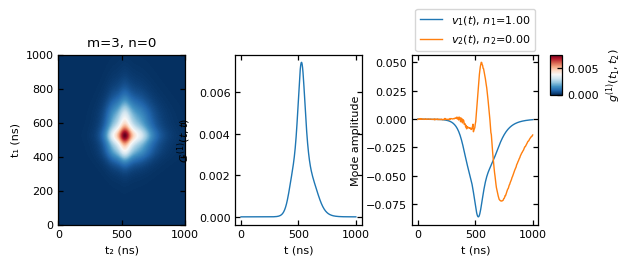

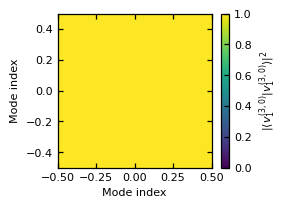

In [26]:
m, n = 0, 3   # データが存在する組だけ

fig, axes = plt.subplots(1, 3, figsize=(6, 2))
plt.subplots_adjust(wspace=0.4, hspace=0.6, left=0.10, right=0.90, top=0.95, bottom=0.1)

G1 = results_output_abs[(m, n)]

Nt = len(tgrid)
dt = tgrid[1] - tgrid[0]

# --- G1_new の構築 ---
G1_new = np.zeros((Nt, Nt), dtype=complex)
for idx_b, t_b in enumerate(tgrid):
    for idx_a, t_a in enumerate(tgrid):
        tau_idx = idx_a - idx_b
        if 0 <= tau_idx < Nt:
            G1_new[idx_a, idx_b] = G1[idx_b, tau_idx]
        else:
            G1_new[idx_a, idx_b] = np.conjugate(G1_new[idx_b, idx_a])

# --- 固有値問題 ---
eigs, eigvecs = np.linalg.eigh(G1_new)
sort_idx = np.argsort(eigs)[::-1]
eigs = eigs[sort_idx]
eigvecs = eigvecs[:, sort_idx]
eigs_frac = eigs / np.sum(eigs)

# --- 1. g1 heatmap ---
im = axes[0].imshow(
    G1_new.real,
    extent=[tgrid[0], tgrid[-1], tgrid[0], tgrid[-1]],
    cmap="RdBu_r",
    origin="lower",
    aspect="auto",
    vmin=np.min(G1_new.real),
    vmax=np.max(G1_new.real)
)
axes[0].set_title("m=3, n=0")
axes[0].set_xlabel("t₂ (ns)")
axes[0].set_ylabel("t₁ (ns)")

# --- 2. diagonal ---
axes[1].plot(tgrid, np.real(np.diag(G1_new)), color='tab:blue')
axes[1].set_xlabel("t (ns)")
axes[1].set_ylabel(r"$G^{(1)}(t,t)$")

# --- 3. principal modes ---
lines = []
labels = []
for k in range(min(2, len(eigs))):
    v = eigvecs[:, k]
    v_norm = v / np.sqrt(np.trapz(np.abs(v)**2, tgrid))
    line, = axes[2].plot(tgrid, np.real(v_norm))
    lines.append(line)
    labels.append(f"$v_{k+1}(t)$, $n_{{{k+1}}}$={eigs_frac[k]:.2f}")

    # principal_mode_dict の最低限の記録
    if k == 0:
        principal_mode_dict[(m, n)] = v_norm.copy()

axes[2].legend(handles=lines, labels=labels, fontsize=8,
               loc='upper center', bbox_to_anchor=(0.5, 1.3))
axes[2].set_xlabel("t (ns)")
axes[2].set_ylabel("Mode amplitude")

# --- カラーバー ---
cbar_ax = fig.add_axes([0.92, 0.75, 0.02, 0.2])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"$g^{(1)}(t_1, t_2)$")

plt.show()

# --- オーバーラップ行列（1個なので 1x1 = 1）---
principal_modes = [principal_mode_dict[(3, 0)]]
overlap_matrix = np.array([[1.0]])  # 自明

fig2, ax2 = plt.subplots(figsize=(2.5, 2.))
im2 = ax2.imshow(overlap_matrix, origin='lower', cmap='viridis', vmin=0, vmax=1)
cbar2 = fig2.colorbar(im2)
cbar2.set_label(r"$|\langle v_1^{(3,0)} | v_1^{(3,0)} \rangle|^2$")
ax2.set_xlabel("Mode index")
ax2.set_ylabel("Mode index")
plt.show()


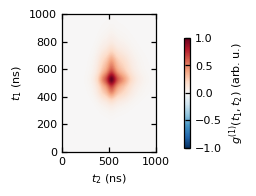

In [28]:
# ---- 外観設定 ----
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 0.9
plt.rcParams['ytick.major.width'] = 0.9
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 0.9
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

# -----------------------
#  m=0, n=3 の1ケースのみ
# -----------------------
m, n = 0, 3

fig, ax = plt.subplots(1, 1, figsize=(2.0, 2.0))  # 1枚だけ
cmap = 'RdBu_r'

Nt = len(tgrid)
dt = tgrid[1] - tgrid[0]

# vmin/vmax 設定（このケースの値から）
G1_raw = results_output_abs[(m, n)]
vmax = np.max(G1_raw.real)
vmin = np.min(G1_raw.real)

# ---- G1_new を作る ----
G1_new = np.zeros((Nt, Nt), dtype=complex)
for idx_b, t_b in enumerate(tgrid):
    for idx_a, t_a in enumerate(tgrid):
        tau_idx = int(idx_a - idx_b)
        if 0 <= tau_idx < Nt:
            G1_new[idx_a, idx_b] = G1[idx_b, tau_idx]
        else:
            G1_new[idx_a, idx_b] = np.conjugate(G1_new[idx_b, idx_a])

# ---- プロット ----
im = ax.imshow(
    G1_new.real / vmax,
    extent=[tgrid[0], tgrid[-1], tgrid[0], tgrid[-1]],
    cmap="RdBu_r",
    origin="lower",
    aspect="auto",
    vmin=-1, vmax=1
)

ax.set_xlabel(r"$t_2$ (ns)")
ax.set_ylabel(r"$t_1$ (ns)")
ax.set_xlim([0, 1000])
ax.set_ylim([0, 1000])

plt.tight_layout(rect=[0, 0, 0.92, 1])

# カラーバー
cbar_ax = fig.add_axes([0.93, 0.25, 0.03, 0.55])
fig.colorbar(im, cax=cbar_ax, label=r"$g^{(1)}(t_1,t_2)$ (arb. u.)")

plt.show()


Overlap = (-0.9148784700546911+0j)
Abs overlap = 0.9148784700546911


C:\Users\qipe\AppData\Local\Temp\ipykernel_3456\3602428518.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(np.abs(wave)**2, dx=dt))
c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\qipe\AppData\Local\Temp\ipykernel_3456\3602428518.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  overlap = np.trapz(np.conjugate(LdL_norm) * orig_norm, dx=dt)


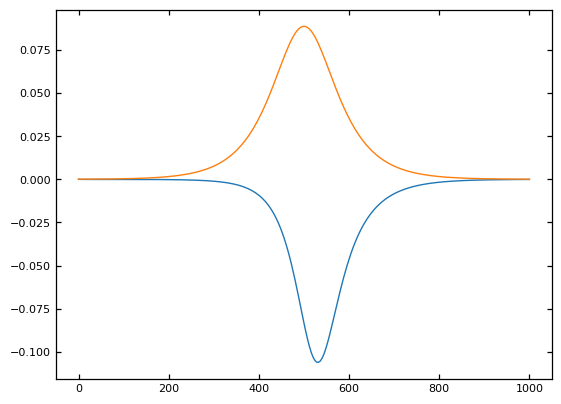

In [326]:
LdL = principal_mode_dict[(0, 1)]
orig = xi_m(tgrid-(tgrid[-1]-tgrid[0])/2, m, kappa_ph)

# 時間刻み dt
dt = tgrid[1] - tgrid[0]

# --- normalize ---
def normalize(wave, dt):
    norm = np.sqrt(np.trapz(np.abs(wave)**2, dx=dt))
    return wave / norm

LdL_norm  = normalize(LdL, dt)
orig_norm = normalize(orig, dt)

plt.plot(tgrid, LdL_norm)
plt.plot(tgrid, orig_norm)

# --- overlap ---
overlap = np.trapz(np.conjugate(LdL_norm) * orig_norm, dx=dt)

print("Overlap =", overlap)
print("Abs overlap =", np.abs(overlap))


In [29]:
# vc for output
kappa_ph = 2.5e-3 * 2 * np.pi * 2
g_v_interps = []
for m in range(4):
    ut_vals = xi_m(tgrid-(t_vals[-1]-t_vals[0])/2, m, kappa_ph)
    cumint = cumulative_trapezoid(np.abs(ut_vals)**2, tgrid, initial=0)
    eps = 1e-14
    denom = np.sqrt(1.0 - cumint + eps)
    g_vals = np.conjugate(ut_vals) / denom

    g_v_interp = interp1d(tgrid, -np.real(g_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    g_v_interps.append(g_v_interp)

# g_v_interps1 = [[None for n in range(4)] for m in range(4)]

# for m in range(4):
#     for n in range(4):

#         v = principal_mode_dict[(m, n)]#    [::-1] 
#         cumint = cumulative_trapezoid(np.abs(v)**2, tgrid, initial=0)
#         eps = 1e-3
#         denom = np.sqrt(cumint + eps)

#         # g_vals = -np.conjugate(v) / denom 
#         t_min_index = int(0.001 * len(tgrid))     # 最初の 5% を無視
#         mask = np.arange(len(tgrid)) >= t_min_index

#         cumint = cumulative_trapezoid(np.abs(v)**2, tgrid, initial=0)

#         denom = np.sqrt(cumint + eps)

#         g_vals = np.zeros_like(v, dtype=complex)
#         g_vals[mask] = -np.conjugate(v[mask]) / denom[mask]
#         g_vals[:t_min_index] = g_vals[t_min_index]   # 安全な定数に

#         g_v_interp = interp1d(tgrid, g_vals, kind='cubic', fill_value='extrapolate')

#         g_v_interps1[m][n] = g_v_interp

# plt.plot(tgrid, g_v_interps[1](tgrid))
# plt.plot(tgrid, -g_v_interps1[1][2](tgrid))

In [39]:
def g_v(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["output_num"])
    return float(args["g_v_interps"][m](t_local))

def g_v_conj(t, args):
    return np.conjugate(g_v(t, args))

def g_u_v(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["input_num"])
    l = int(args["output_num"])
    return float(args["g_u_interps"][m](t_local)*np.conjugate(args["g_v_interps"][l](t_local)))

def g_u_v_conj(t, args):
    return np.conjugate(g_u_v(t, args))

n_cutoff_q = 3
n_cutoff_r = 2
n_cutoff_vc = 3
n_cutoff_vco = 3

b = qt.tensor(qt.destroy(n_cutoff_q), qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.qeye(n_cutoff_vco))
a = qt.tensor(qt.qeye(n_cutoff_q), qt.destroy(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.qeye(n_cutoff_vco))
vc = qt.tensor(qt.qeye(n_cutoff_q), qt.qeye(n_cutoff_r), qt.destroy(n_cutoff_vc), qt.qeye(n_cutoff_vco))
vco = qt.tensor(qt.qeye(n_cutoff_q), qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.destroy(n_cutoff_vco))

zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,1]=1
gedecayop=Qobj(zeromatrixxtmp)
etog = qt.tensor(gedecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.qeye(n_cutoff_vco))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,2]=1
efdecayop=Qobj(zeromatrixxtmp)
ftoe = qt.tensor(efdecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.qeye(n_cutoff_vco))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,0]=-1
zeromatrixxtmp[1,1]=1
gedechoop=Qobj(zeromatrixxtmp)
dechoge = qt.tensor(gedechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.qeye(n_cutoff_vco))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,1]=-1
zeromatrixxtmp[2,2]=1
efdechoop=Qobj(zeromatrixxtmp)
dechoef = qt.tensor(efdechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.qeye(n_cutoff_vco))

g0 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0), qt.basis(n_cutoff_vco, 0))
f0 = qt.tensor(qt.basis(n_cutoff_q, 2), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0), qt.basis(n_cutoff_vco, 0))
g1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 1), qt.basis(n_cutoff_vc, 0), qt.basis(n_cutoff_vco, 0))
e0 = qt.tensor(qt.basis(n_cutoff_q, 1), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0), qt.basis(n_cutoff_vco, 0))
vc1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1), qt.basis(n_cutoff_vco, 0))

alpha = -0.356 * 2 * np.pi
chi = -0.0076 * 2 * np.pi
eta = 0.67
eff = 0.9
kappa_r = 0.14 * 2 * np.pi
K = 0 * 2 * np.pi

H_fogi = (
    -alpha / 2 * b.dag()*b + alpha * b.dag()*b.dag()*b*b / 2
    +K * a.dag()*a.dag()*a*a / 2 + 2*chi*a.dag()*a*b.dag()*b
)

H_d = -a.dag()*b*b/np.sqrt(2)
H_c = 1j *np.sqrt(eta)*np.sqrt(eff)* (np.sqrt(kappa_r)/2) * vc.dag()*a
H_co = 1j *np.sqrt(eta)*np.sqrt(eff)* (np.sqrt(kappa_r)/2) * a.dag()*vco
H_cco = 1j /2 * vc.dag()*vco

e_ops = []
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=1000, max_step=0.1, store_states=True)

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


In [40]:
l=0
base_args = {
    "center": 0,
    "fogi_mode": 3,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "g_v_interps": g_v_interps,
    "input_num": 0,
    "output_num": 0,
    "input": 1,
}
results = {} 

initial_states = {
    "g0": g0,
    "vc1": vc1,
    "g0+vc1": (g0 + vc1).unit(),
    "g0-i*vc1": (g0 - 1j*vc1).unit(),
    "g0+i*vc1": (g0 + 1j*vc1).unit(),
    "g0-vc1": (g0 - vc1).unit()
}

m = 0
n = 3 

results = {}

for label, psi0_m in initial_states.items():
    args_mn = base_args.copy()
    args_mn["input_num"] = m
    args_mn["fogi_mode"] = n
    args_mn["output_num"] = m

    H_m = [
        H_fogi,
        [H_c, g_u], [H_c.dag(), g_u_conj],
        [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
        [H_co, g_v_conj], [H_co.dag(), g_v],
        [H_cco, g_u_v], [H_cco.dag(), g_u_v_conj],
    ]

    def total_c_op(t, args):
        return np.conjugate(g_u(t, args)) * vc + np.conjugate(g_v(t, args)) * vco + np.sqrt(kappa_r) * a

    c_ops_mn = [
        total_c_op,
        np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
        np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
    ]

    result_mn = qt.mesolve(
        H_m, psi0_m, tgrid-tgrid[0], c_ops_mn, e_ops=e_ops,
        args=args_mn, options=options, progress_bar=True
    )

    results[(m, n, label)] = result_mn
    print(f"Finished simulation for initial state: {label}")

import json

with h5py.File("results_output_qstate_0122.h5", "w") as f:
    for (m, n, label), result_mn in results.items():
        group_name = f"m{m}/n{n}/{label}"
        grp = f.create_group(group_name)

        for ti, rho in enumerate(result_mn.states):
            sgrp = grp.create_group(f"state_{ti}")
            sgrp.create_dataset("data", data=rho.full())
            sgrp.attrs["dims"] = json.dumps(rho.dims)

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


10.0%. Run time:   9.16s. Est. time left: 00:00:01:22
20.0%. Run time:  18.29s. Est. time left: 00:00:01:13
30.0%. Run time:  27.47s. Est. time left: 00:00:01:04
40.0%. Run time:  36.68s. Est. time left: 00:00:00:55
50.0%. Run time:  46.11s. Est. time left: 00:00:00:46
60.0%. Run time:  55.47s. Est. time left: 00:00:00:36
70.0%. Run time:  64.69s. Est. time left: 00:00:00:27
80.0%. Run time:  74.08s. Est. time left: 00:00:00:18
90.0%. Run time:  83.61s. Est. time left: 00:00:00:09
100.0%. Run time:  92.79s. Est. time left: 00:00:00:00
Total run time:  92.79s
Finished simulation for initial state: g0
10.0%. Run time:   9.60s. Est. time left: 00:00:01:26
20.0%. Run time:  19.36s. Est. time left: 00:00:01:17
30.0%. Run time:  28.71s. Est. time left: 00:00:01:06
40.0%. Run time:  37.93s. Est. time left: 00:00:00:56
50.0%. Run time:  47.19s. Est. time left: 00:00:00:47
60.0%. Run time:  56.54s. Est. time left: 00:00:00:37
70.0%. Run time:  66.02s. Est. time left: 00:00:00:28
80.0%. Run time

Plotting m=0, n=3


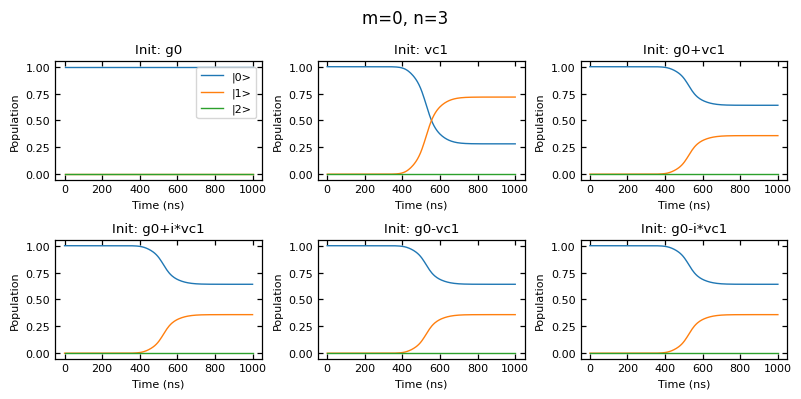

In [41]:
import h5py, json
def load_all_states(filename, m, n, label):

    with h5py.File(filename, "r") as f:
        group = f[f"m{m}/n{n}/{label}"]
        keys = sorted(group.keys(), key=lambda s: int(s.split('_')[1]))
        states = []
        for k in keys:
            rho_data = group[k]["data"][()]
            dims = json.loads(group[k].attrs["dims"])
            states.append(qt.Qobj(rho_data, dims=dims))
    return states

filename = "results_output_qstate_0122.h5"

initial_labels = ["g0", "vc1", "g0+vc1", "g0+i*vc1", "g0-vc1", "g0-i*vc1"]
e_labels = ["|0>", "|1>", "|2>"]  # 対象モードの Fock 0,1,2
target_mode = 3

for m in range(1):
    m=0
    for n in range(1):
        n=3
        if m == n:
            continue  # m=n をスキップ
        
        print(f"Plotting m={m}, n={n}")

        fig, axes = plt.subplots(2, 3, figsize=(8, 4))
        axes = axes.ravel()

        for idx, label in enumerate(initial_labels):
            states = load_all_states(filename, m=m, n=n, label=label)
            tlist = np.arange(len(states)) * dt

            ax = axes[idx]
            for i, l in enumerate(e_labels):
                pop = [state.ptrace(target_mode).full()[i, i].real for state in states]
                ax.plot(tlist, pop, label=l)

            ax.set_title(f"Init: {label}")
            ax.set_xlabel("Time (ns)")
            ax.set_ylabel("Population")
            if idx == 0:
                ax.legend(fontsize=8)

        fig.suptitle(f"m={m}, n={n}", fontsize=12)
        plt.tight_layout()
        plt.show()




Plotting m=0, n=3


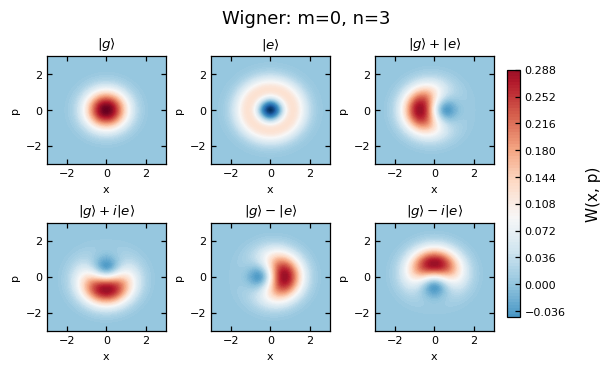

In [42]:
def load_final_state(filename, m, n, label):
    with h5py.File(filename, "r") as f:
        group = f[f"m{m}/n{n}/{label}"]
        keys = sorted(group.keys(), key=lambda s: int(s.split('_')[1]))
        last = group[keys[-1]]

        rho_data = last["data"][()]
        dims = json.loads(last.attrs["dims"])

        return qt.Qobj(rho_data, dims=dims)

xvec = np.linspace(-3, 3, 200)
initial_labels = ["g0", "vc1", "g0+vc1", "g0+i*vc1", "g0-vc1", "g0-i*vc1"]
initial_labels_tex = [r"$|g\rangle$", r"$|e\rangle$", r"$|g\rangle+|e\rangle$", 
                      r"$|g\rangle+i|e\rangle$", r"$|g\rangle-|e\rangle$", r"$|g\rangle-i|e\rangle$"]

m=0
n=3
W_all = []
for label in initial_labels:
    rho_total = load_final_state(filename, m, n, label)
    rho_vco = rho_total.ptrace(3)
    W_vco = qt.wigner(rho_vco, xvec, xvec)
    W_all.append(W_vco)

W_stack = np.array(W_all)
vmin, vmax = W_stack.min(), W_stack.max()

for m in range(1):
    m=0
    for n in range(1):
        n=3
        if m == n:
            continue

        print(f"Plotting m={m}, n={n}")

        W_all = []
        for label in initial_labels:
            rho_total = load_final_state(filename, m, n, label)
            rho_vco = rho_total.ptrace(3)
            W_vco = qt.wigner(rho_vco, xvec, xvec)
            W_all.append(W_vco)


        fig, axes = plt.subplots(2, 3, figsize=(6, 3.6), constrained_layout=True)
        axes = axes.ravel()

        for i, label in enumerate(initial_labels_tex):
            W_vco = W_all[i]
            im = axes[i].contourf(
                xvec, xvec, W_vco, 100, cmap="RdBu_r",
                vmin=vmin, vmax=vmax
            )
            axes[i].set_title(label)
            axes[i].set_xlabel("x")
            axes[i].set_ylabel("p")

        cbar = fig.colorbar(im, ax=axes, orientation="vertical",
                            shrink=0.9, pad=0.03)
        cbar.set_label("W(x, p)", rotation=90, labelpad=15, fontsize=11)

        fig.suptitle(f"Wigner: m={m}, n={n}", fontsize=13)

        plt.show()



===== m=0, n=3 =====
→ Using initial_labels_pi (sign flipped order)


C:\Users\qipe\AppData\Local\Temp\ipykernel_13088\1658533081.py:131: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


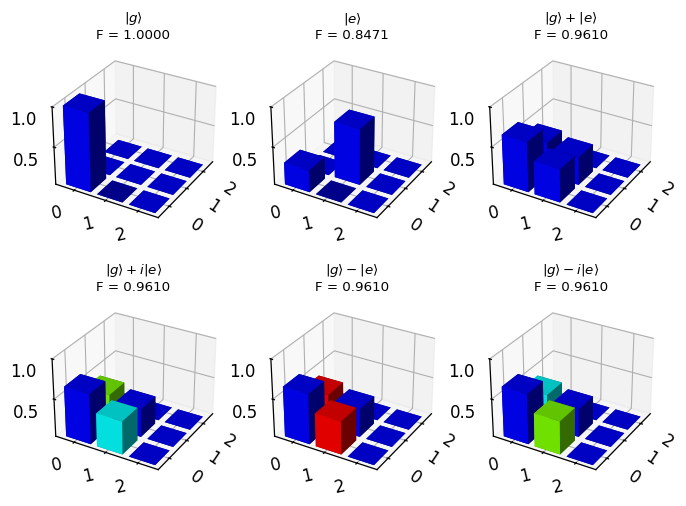

<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)


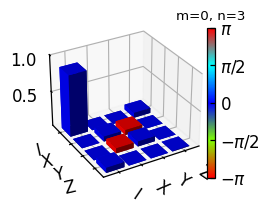

chi : [[ 8.52944228e-01+0.00000000e+00j  0.00000000e+00-2.52575738e-14j
   2.52575738e-14+0.00000000e+00j  7.06033415e-02+0.00000000e+00j]
 [ 0.00000000e+00+2.52575738e-14j  7.06033415e-02+0.00000000e+00j
  -7.06033415e-02+0.00000000e+00j -2.52575738e-14+0.00000000e+00j]
 [ 2.52575738e-14+0.00000000e+00j -7.06033415e-02+0.00000000e+00j
   7.06033415e-02+0.00000000e+00j  0.00000000e+00-2.52575738e-14j]
 [ 7.06033415e-02+0.00000000e+00j -2.52575738e-14+0.00000000e+00j
   0.00000000e+00+2.52575738e-14j  5.84908933e-03+0.00000000e+00j]]
Process fidelity : 0.85294
Process chi fidelity : 0.85294+0.00000j


In [43]:
initial_labels = ["g0", "vc1", "g0+vc1", "g0+i*vc1", "g0-vc1", "g0-i*vc1"]
initial_labels_tex = [r"$|g\rangle$", r"$|e\rangle$", r"$|g\rangle+|e\rangle$", 
                      r"$|g\rangle+i|e\rangle$", r"$|g\rangle-|e\rangle$", r"$|g\rangle-i|e\rangle$"]


def compute_fidelities_for_labelset(filename, m, n, initial_labels, ideals, target_mode):
    fidelities = {}
    reduced_qubits = {}
    rho_fulls = {}

    for label in initial_labels:
        # load full multi-mode density matrix
        rho_total = load_final_state(filename, m, n, label)

        # partial trace
        try:
            rho_mode = rho_total.ptrace(target_mode)
        except Exception as e:
            print(f"ptrace failed for {label} with target_mode={target_mode}: {e}")
            rho_mode = rho_total

        rho_mode_mat = np.array(rho_mode.full(), dtype=complex)

        # truncate/expand to 3x3
        rho_3_mat = np.zeros((3, 3), dtype=complex)
        n_dim = min(rho_mode_mat.shape[0], 3)
        rho_3_mat[:n_dim, :n_dim] = rho_mode_mat[:n_dim, :n_dim]
        rho_3 = qt.Qobj(rho_3_mat, dims=[[3], [3]])

        # store
        reduced_qubits[label] = rho_3
        rho_fulls[label] = rho_mode

        # fidelity with ideal
        if label in ideals:
            fid = float(qt.metrics.fidelity(rho_3, ideals[label]))
        else:
            fid = None

        fidelities[label] = fid

    # 合計値（None を除外）
    total_fid = sum(f for f in fidelities.values() if f is not None)

    return total_fid, fidelities, reduced_qubits, rho_fulls


def evaluate_state_transfer_three_level(
    filename="results_output_qstate.h5",
    m=0, n=3,
    initial_labels=None,
    initial_labels_pi=None,
    target_mode=3,
    plot_results=True
):

    if initial_labels is None:
        initial_labels = ["g0", "vc1", "g0+vc1", "g0+i*vc1", "g0-vc1", "g0-i*vc1"]

    b0 = qt.basis(2, 0)
    b1 = qt.basis(2, 1)
    ideals_2 = {
        "g0": b0.proj(),
        "vc1": b1.proj(),
        "g0+vc1": (b0 + b1).unit().proj(),
        "g0+i*vc1": (b0 + 1j*b1).unit().proj(),
        "g0-vc1": (b0 - b1).unit().proj(),
        "g0-i*vc1": (b0 - 1j*b1).unit().proj(),
    }
    # 3x3に拡張
    ideals = {}
    for k, rho2 in ideals_2.items():
        rho3_mat = np.zeros((3, 3), dtype=complex)
        rho3_mat[:2, :2] = rho2.full()  # numpy 配列に代入
        rho3_mat[2, 2] = 0.0            # population=0
        rho3 = qt.Qobj(rho3_mat, dims=[[3], [3]])  # Qobj に変換
        ideals[k] = rho3

    ideals_2_pi = {
        "g0": b0.proj(),
        "vc1": b1.proj(),
        "g0+vc1": (b0 - b1).unit().proj(),
        "g0+i*vc1": (b0 - 1j*b1).unit().proj(),
        "g0-vc1": (b0 + b1).unit().proj(),
        "g0-i*vc1": (b0 + 1j*b1).unit().proj(),
    }
    # 3x3に拡張
    ideals_pi = {}
    for k, rho2 in ideals_2_pi.items():
        rho3_mat = np.zeros((3, 3), dtype=complex)
        rho3_mat[:2, :2] = rho2.full()  # numpy 配列に代入
        rho3_mat[2, 2] = 0.0            # population=0
        rho3 = qt.Qobj(rho3_mat, dims=[[3], [3]])  # Qobj に変換
        ideals_pi[k] = rho3

    fidelities = {}
    reduced_qubits = {}
    rho_fulls = {}

    total1, fidelities1, reduced1, full1 = compute_fidelities_for_labelset(
        filename, m, n, initial_labels, ideals, target_mode
    )

    total2, fidelities2, reduced2, full2 = compute_fidelities_for_labelset(
        filename, m, n, initial_labels, ideals_pi, target_mode
    )

    if total1 >= total2:
        chosen_labels = initial_labels
        fidelities = fidelities1
        reduced_qubits = reduced1
        rho_fulls = full1
        print("→ Using initial_labels (normal order)")
    else:
        chosen_labels = initial_labels_pi
        fidelities = fidelities2
        reduced_qubits = reduced2
        rho_fulls = full2
        print("→ Using initial_labels_pi (sign flipped order)")
        # optional plotting: 3x3 density matrices

    if plot_results:
        labels_tex = [r"$|g\rangle$", r"$|e\rangle$", r"$|g\rangle+|e\rangle$",
                      r"$|g\rangle+i|e\rangle$", r"$|g\rangle-|e\rangle$", r"$|g\rangle-i|e\rangle$"]
        fig, axes = plt.subplots(2, 3, figsize=(8, 6), subplot_kw={"projection": "3d"})
        axes = axes.ravel()
        for i, label in enumerate(chosen_labels):
            ax = axes[i]
            ysq.matrix_histogram_complex(reduced_qubits[label], ax=ax, colorbar=False)
            ax.set_title(f"{labels_tex[i]}\nF = {fidelities[label]:.4f}")
        plt.tight_layout()
        plt.show()

    return {"fidelities": fidelities, "reduced_qubits": reduced_qubits, "rho_modes": rho_fulls}

def chi_fidelity(chi:np.ndarray, chi_ideal:np.ndarray):
    print(type(chi), chi.dtype, chi.shape)
    print(type(chi_ideal), chi_ideal.dtype, chi_ideal.shape)
    return np.trace(chi @ chi_ideal)

order = ["g0", "g0+vc1", "g0+i*vc1", "vc1", "g0-vc1", "g0-i*vc1"]
order_mi = ["g0", "g0-vc1", "g0-i*vc1", "vc1", "g0+vc1", "g0+i*vc1"]
I = np.array([
            [1, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
        ])
initial_labels_pi = ["g0", "vc1", "g0-vc1", "g0-i*vc1", "g0+vc1", "g0+i*vc1"]
m_list = range(1)
n_list = range(1)

for m in m_list:
    m=0
    for n in n_list:
        n=3
        if m == n:
            continue

        print(f"===== m={m}, n={n} =====")

        res = evaluate_state_transfer_three_level(
            filename=filename,
            m=m,
            n=n,
            initial_labels=initial_labels,
            initial_labels_pi=initial_labels_pi,
            target_mode=3,
            plot_results=True
        )

        chi_input_pl = [res["reduced_qubits"][k].full()[:2, :2] for k in order]
        chi_input_mi = [res["reduced_qubits"][k].full()[:2, :2] for k in order_mi]
        chi_pl = QPT_MaxLik_Qubit(chi_input_pl)
        chi_mi = QPT_MaxLik_Qubit(chi_input_mi)
        fid_pl = chi_fidelity(I, chi_pl)
        fid_mi = chi_fidelity(I, chi_mi)

        chi = chi_pl if fid_pl >= fid_mi else chi_mi
        ysq.matrix_histogram_complex(
            chi,
            fig=plt.figure(figsize=(2,2)),
            xlabels=["I", "X", "Y", "Z"],
            ylabels=["I", "X", "Y", "Z"]
        )
        plt.title(f"m={m}, n={n}")
        plt.show()

        
        print(f"chi : {chi}")
        print(f"Process fidelity : {fidelity(Qobj(I), Qobj(chi))**2 :.5f}")
        print(f"Process chi fidelity : {max(fid_pl, fid_mi) :.5f}")



In [44]:
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

→ Using initial_labels_pi (sign flipped order)


C:\Users\qipe\AppData\Local\Temp\ipykernel_13088\2611283089.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\qipe\AppData\Local\Temp\ipykernel_13088\2611283089.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


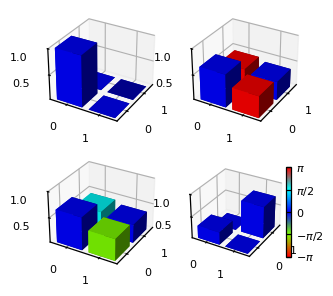

In [45]:
import matplotlib as mpl
from scipy.constants import pi
from qutip.matplotlib_utilities import complex_phase_cmap

cmap = complex_phase_cmap()
m, n = 0, 3
res = evaluate_state_transfer_three_level(
    filename=filename,
    m=m,
    n=n,
    initial_labels=initial_labels,
    initial_labels_pi=initial_labels_pi,
    target_mode=3,
    plot_results=False 
)

selected_labels = ["g0", "g0+vc1", "g0+i*vc1", "vc1"]
selected_labels_tex = [r"$|g\rangle$", r"$|g\rangle-|e\rangle$", r"$|g\rangle+i|e\rangle$", r"$|e\rangle$"]

chi_input_selected = [res["reduced_qubits"][k].full()[:2, :2] for k in selected_labels]

fig, axes = plt.subplots(2, 2, figsize=(3.4,3.4), subplot_kw={"projection": "3d"})
axes = axes.ravel()

mesh_last = None

for i, label in enumerate(selected_labels):
    ax = axes[i]
    mesh_last, _ = ysq.matrix_histogram_complex(
        qt.Qobj(chi_input_selected[i]), ax=ax, colorbar=False
    )
    ax.tick_params(axis='both', labelsize=8)
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(0)

    for lbl in ax.get_yticklabels():
        lbl.set_rotation(0)
norm = mpl.colors.Normalize(-pi, pi)
cax, kw = mpl.colorbar.make_axes(ax, shrink=.75, pad=.0)
cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm)
cb.set_ticks([-pi, -pi / 2, 0, pi / 2, pi])
cb.set_ticklabels((r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'))
cb.ax.tick_params(labelsize=8) 
plt.tight_layout()
plt.show()


# m, n = 3, 0
# res = evaluate_state_transfer_three_level(
#     filename=filename,
#     m=m,
#     n=n,
#     initial_labels=initial_labels,
#     initial_labels_pi=initial_labels_pi,
#     target_mode=3,
#     plot_results=False 
# )

# selected_labels = ["g0", "g0-vc1", "g0+i*vc1", "vc1"]
# selected_labels_tex = [r"$|g\rangle$", r"$|g\rangle-|e\rangle$", r"$|g\rangle+i|e\rangle$", r"$|e\rangle$"]

# chi_input_selected = [res["reduced_qubits"][k].full()[:2, :2] for k in selected_labels]

# fig, axes = plt.subplots(2, 2, figsize=(3.4,3.4), subplot_kw={"projection": "3d"})
# axes = axes.ravel()

# mesh_last = None

# for i, label in enumerate(selected_labels):
#     ax = axes[i]
#     mesh_last, _ = ysq.matrix_histogram_complex(
#         qt.Qobj(chi_input_selected[i]), ax=ax, colorbar=False
#     )
#     ax.tick_params(axis='both', labelsize=8)
#     for lbl in ax.get_xticklabels():
#         lbl.set_rotation(0)

#     for lbl in ax.get_yticklabels():
#         lbl.set_rotation(0)

# cax, kw = mpl.colorbar.make_axes(ax, shrink=.75, pad=.0)
# cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm)
# cb.set_ticks([-pi, -pi / 2, 0, pi / 2, pi])
# cb.set_ticklabels((r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'))
# cb.ax.tick_params(labelsize=8) 
# # cb.set_label('偏\n角', fontsize=15, rotation=0, verticalalignment='center', horizontalalignment='right')


# plt.tight_layout()
# plt.show()


→ Using initial_labels_pi (sign flipped order)


C:\Users\qipe\AppData\Local\Temp\ipykernel_13088\3980665311.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # 右にカラーバー用スペース確保
C:\Users\qipe\AppData\Local\Temp\ipykernel_13088\3980665311.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # 右にカラーバー用スペース確保


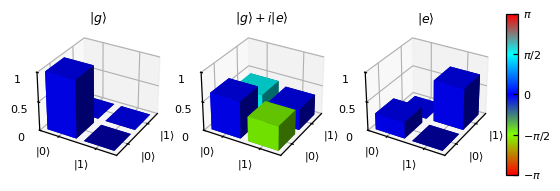

In [51]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.constants import pi
from qutip.matplotlib_utilities import complex_phase_cmap

cmap = complex_phase_cmap()
norm = mpl.colors.Normalize(-pi, pi)

def plot_chi_selected(res, selected_labels, selected_labels_tex):
    chi_input_selected = [res["reduced_qubits"][k].full()[:2, :2] for k in selected_labels]

    # ---- 1行3列に変更 ----
    fig, axes = plt.subplots(
        1, 3, figsize=(6.0, 2.3),
        subplot_kw={"projection": "3d"}
    )

    if len(selected_labels) != 3:
        raise ValueError("selected_labels must have exactly 3 elements.")

    for i, label in enumerate(selected_labels):
        ax = axes[i]
        ysq.matrix_histogram_complex(qt.Qobj(chi_input_selected[i]), ax=ax, colorbar=False)

        # ---- XY 軸ラベル ----
        ax.set_xticks([0, 1])
        ax.set_xticklabels([r"$|0\rangle$", r"$|1\rangle$"], fontsize=8, rotation=0)

        ax.set_yticks([0, 1])
        ax.set_yticklabels([r"$|0\rangle$", r"$|1\rangle$"], fontsize=8, rotation=0)

        # ---- Z 軸 ----
        ax.set_zticks([0, 0.5, 1.0])
        ax.set_zticklabels(["0", "0.5", "1"], fontsize=8)

        # ticks margin
        ax.tick_params(axis='x', pad=0)
        ax.tick_params(axis='y', pad=0)
        ax.tick_params(axis='z', pad=0)

        # title
        ax.set_title(selected_labels_tex[i], fontsize=9, pad=-2)

    # ---- 右側に縦カラーバー ----
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.70])  # 右側に縦
    cb = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation='vertical')

    cb.set_ticks([-pi, -pi/2, 0, pi/2, pi])
    cb.set_ticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
    cb.ax.tick_params(labelsize=8)

    plt.tight_layout(rect=[0, 0, 0.9, 1])  # 右にカラーバー用スペース確保

m, n = 0, 3
res = evaluate_state_transfer_three_level(
    filename=filename,
    m=m,
    n=n,
    initial_labels=initial_labels,
    initial_labels_pi=initial_labels_pi,
    target_mode=3,
    plot_results=False 
)

selected_labels = ["g0", "g0+i*vc1", "vc1"]
selected_labels_tex = [
    r"$|g\rangle$",
    r"$|g\rangle+i|e\rangle$",
    r"$|e\rangle$",
]

plot_chi_selected(res, selected_labels, selected_labels_tex)
plt.show()


→ Using initial_labels_pi (sign flipped order)


C:\Users\qipe\AppData\Local\Temp\ipykernel_13088\2399751525.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])
C:\Users\qipe\AppData\Local\Temp\ipykernel_13088\2399751525.py:54: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


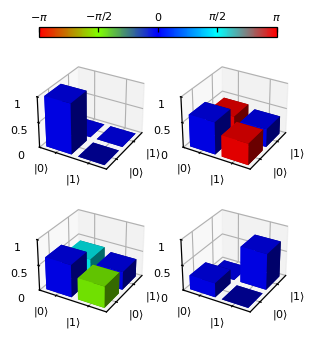

In [50]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.constants import pi
from qutip.matplotlib_utilities import complex_phase_cmap

cmap = complex_phase_cmap()
norm = mpl.colors.Normalize(-pi, pi)

def plot_chi_selected(res, selected_labels, selected_labels_tex):
    chi_input_selected = [res["reduced_qubits"][k].full()[:2, :2] for k in selected_labels]

    fig, axes = plt.subplots(2, 2, figsize=(3.4,3.4), subplot_kw={"projection": "3d"})
    axes = axes.ravel()

    for i, label in enumerate(selected_labels):
        ax = axes[i]
        ysq.matrix_histogram_complex(qt.Qobj(chi_input_selected[i]), ax=ax, colorbar=False)

        # ---- XY 軸ラベルを |0>, |1> にする ----
        ax.set_xticks([0, 1])
        ax.set_xticklabels([r"$|0\rangle$", r"$|1\rangle$"], fontsize=8, rotation=0)

        ax.set_yticks([0, 1])
        ax.set_yticklabels([r"$|0\rangle$", r"$|1\rangle$"], fontsize=8, rotation=0)
        
        # ---- Z 軸の tick を 0, 0.5, 1 に固定 ----
        ax.set_zticks([0, 0.5, 1.0])
        ax.set_zticklabels(["0", "0.5", "1"], fontsize=8)
        # ax.set_zlabel(r"$|\chi_{ij}|$", labelpad=-6, rotation=180)
        # ax.set_zlabel("")

        # x_pos = 0  # X軸方向の位置（適宜調整）
        # y_pos = 0  # Y軸方向の位置（適宜調整）
        # z_pos = 0.5   # Z軸方向の位置（中央あたり）

        # ax.text(x_pos, y_pos, z_pos, r"$|\chi_{ij}|$", 
        #     rotation=90, rotation_mode='anchor', ha='center', va='center')

        # tick の余白調整
        ax.tick_params(axis='x', pad=0)
        ax.tick_params(axis='y', pad=0)
        ax.tick_params(axis='z', pad=0)

    # ---- figure 全体の上に位相カラーバー ----
    cbar_ax = fig.add_axes([0.15, 0.94, 0.7, 0.03])
    cb = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation='horizontal')
    cb.set_ticks([-pi, -pi/2, 0, pi/2, pi])
    cb.set_ticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
    cb.ax.tick_params(labelsize=8)
    cb.ax.xaxis.set_ticks_position('top')
    cb.ax.xaxis.set_label_position('top')
    # cb.set_label("Phase (rad)")

    plt.tight_layout(rect=[0, 0, 1, 0.92])


m, n = 0, 3
res = evaluate_state_transfer_three_level(
    filename=filename,
    m=m,
    n=n,
    initial_labels=initial_labels,
    initial_labels_pi=initial_labels_pi,
    target_mode=3,
    plot_results=False 
)

selected_labels = ["g0", "g0+vc1", "g0+i*vc1", "vc1"]
selected_labels_tex = [r"$|g\rangle$", r"$|g\rangle-|e\rangle$", r"$|g\rangle+i|e\rangle$", r"$|e\rangle$"]

plot_chi_selected(res, selected_labels, selected_labels_tex)
# plt.savefig('Figapp5_b1.pdf', bbox_inches='tight')
plt.show()

# m, n = 3, 0
# res = evaluate_state_transfer_three_level(
#     filename=filename,
#     m=m,
#     n=n,
#     initial_labels=initial_labels,
#     initial_labels_pi=initial_labels_pi,
#     target_mode=3,
#     plot_results=False 
# )

# selected_labels = ["g0", "g0-vc1", "g0-i*vc1", "vc1"]
# selected_labels_tex = [r"$|g\rangle$", r"$|g\rangle-|e\rangle$", r"$|g\rangle+i|e\rangle$", r"$|e\rangle$"]

# plot_chi_selected(res, selected_labels, selected_labels_tex)
# # plt.savefig('Figapp5_c1.pdf', bbox_inches='tight')
# plt.show()

In [1]:
def plot_absorption_rate_matrix(data, ax):
    extent = (0, 3, 0, 3)

    # --- 対角成分を NaN にする（右上→左下）---
    data_plot = data.copy().astype(float)
    for m in range(4):
        n = 3 - m
        data_plot[m, n] = np.nan

    # imshow
    im = ax.imshow(data_plot, extent=extent, filternorm=False, vmin=0, vmax=1)

    # colorbar
    colorbar = plt.colorbar(im, ax=ax, label="Fidelity")
    colorbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1])

    ax.set_ylabel(r"Sender mode $m$")
    ax.set_xlabel(r"Receiver mode $n$")

    ax.tick_params(top=True, bottom=True, left=True, right=True)

    num_x = data.shape[1]
    num_y = data.shape[0]
    x_ticks = np.linspace(0.37, 2.63, num_x)
    y_ticks = np.linspace(0.37, 2.63, num_y)

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(range(num_x))
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(range(num_y))

    # ---- テキスト描画（右上→左下は空白） ----
    for m in range(num_y):       # sender (y)
        for n in range(num_x):   # receiver (x)

            if m + n == 3:       # ←ここが白抜きの条件！
                continue         # セルは空白

            value = rf"{data[m, n]:.2f}"
            color = "red" if data[m, n] > 0.5 else "white"

            # y は反転して 3 - y_ticks[m]
            ax.text(
                x_ticks[n],
                3 - y_ticks[m],
                value,
                ha='center', va='center',
                color=color,
                fontsize=8
            )


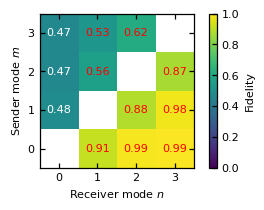

In [100]:
fig, ax = plt.subplots(figsize=(4, 2))
i = 17
data = np.array([[0.465, 0.527, 0.616, 0],
                [0.466, 0.563, 0, 0.871],
                [0.485, 0, 0.884, 0.980],
                [0, 0.914, 0.988, 0.995]])

plot_absorption_rate_matrix(data, ax)
plt.savefig('Figapp5_d1.pdf', bbox_inches='tight')
plt.show()

In [5]:
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.


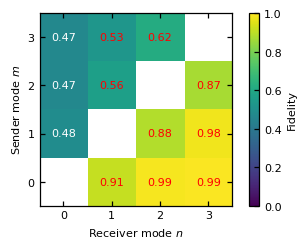

In [9]:
fig, ax = plt.subplots(figsize=(4.5, 2.5))
i = 17
data = np.array([[0.465, 0.527, 0.616, 0],
                [0.466, 0.563, 0, 0.871],
                [0.485, 0, 0.884, 0.980],
                [0, 0.914, 0.988, 0.995]])

plot_absorption_rate_matrix(data, ax)
plt.savefig('Figapp5_d2.pdf', bbox_inches='tight')
plt.show()

In [ ]:
def load_final_state(filename, m, n, label):
    with h5py.File(filename, "r") as f:
        group = f[f"m{m}/n{n}/{label}"]
        keys = sorted(group.keys(), key=lambda s: int(s.split('_')[1]))
        last = group[keys[-1]]

        rho_data = last["data"][()]
        dims = json.loads(last.attrs["dims"])

        return qt.Qobj(rho_data, dims=dims)

xvec = np.linspace(-3, 3, 200)

m=0
n=3
W_all = []
for label in initial_labels:
    rho_total = load_final_state(filename, m, n, label)
    rho_vco = rho_total.ptrace(3)
    W_vco = qt.wigner(rho_vco, xvec, xvec)
    W_all.append(W_vco)

W_stack = np.array(W_all)
vmin, vmax = W_stack.min(), W_stack.max()

for m in range(4):
    for n in range(4):
        if m == n:
            continue

        print(f"Plotting m={m}, n={n}")

        W_all = []
        for label in initial_labels:
            rho_total = load_final_state(filename, m, n, label)
            rho_vco = rho_total.ptrace(3)
            W_vco = qt.wigner(rho_vco, xvec, xvec)
            W_all.append(W_vco)


        fig, axes = plt.subplots(2, 3, figsize=(6, 3.6), constrained_layout=True)
        axes = axes.ravel()

        for i, label in enumerate(initial_labels_tex):
            W_vco = W_all[i]
            im = axes[i].contourf(
                xvec, xvec, W_vco, 100, cmap="RdBu_r",
                vmin=vmin, vmax=vmax
            )
            axes[i].set_title(label)
            axes[i].set_xlabel("x")
            axes[i].set_ylabel("p")

        cbar = fig.colorbar(im, ax=axes, orientation="vertical",
                            shrink=0.9, pad=0.03)
        cbar.set_label("W(x, p)", rotation=90, labelpad=15, fontsize=11)

        fig.suptitle(f"Wigner: m={m}, n={n}", fontsize=13)

        plt.show()



c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


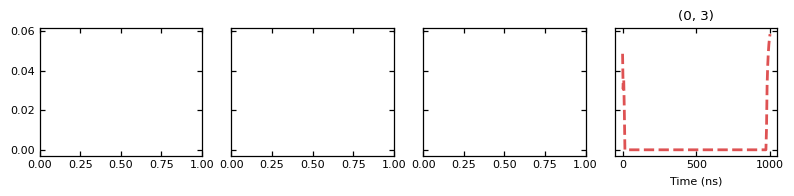

In [249]:
for m in range(1): 
    fig, axes = plt.subplots(1, 4, figsize=(8, 2), sharey=True)
    plt.subplots_adjust(wspace=0.4)

    for n in range(1):
        n=n+3
        states = results[(m, n)].states
        vcdvc_s = qt.expect(vc.dag() * vc, states)
        vcodvco_s = qt.expect(vco.dag() * vco, states)
        ada_s = qt.expect(a.dag() * a, states)
        vcda_s = qt.expect(vc.dag() * a, states)
        advc_s = qt.expect(a.dag() * vc, states)
        vcoda_s = qt.expect(vco.dag() * a, states)
        advco_s = qt.expect(a.dag() * vco, states)
        vcodvc_s = qt.expect(vco.dag() * vc, states)
        vcdvco_s = qt.expect(vc.dag() * vco, states)
        args = {
            "center": 0,
            "fogi_mode": n,
            "g_interps": g_interps,
            "g_interps_rvs": g_interps_rvs,
            "g_u_interps": g_u_interps,
            "g_v_interps": g_v_interps,
            "input_num": m,
            "output_num": m,
            # "input": 0,
        }  

        gu_values = np.array([g_u(t, args) for t in tgrid])
        gv_values = np.array([g_v(t, args) for t in tgrid])
        guv_values = -np.array([g_u(t, args)*np.conjugate(g_v(t, args)) for t in tgrid])
        
        LdL = (
            gu_values * np.conjugate(gu_values) * vcdvc_s + kappa_r * ada_s + gv_values * np.conjugate(gv_values) * vcodvco_s
            + np.sqrt(kappa_r) * (gu_values * vcda_s + np.conjugate(gu_values) * advc_s)
            + np.sqrt(kappa_r) * (gv_values * vcoda_s + np.conjugate(gv_values) * advco_s)
            + guv_values * vcdvco_s + np.conjugate(guv_values) * vcodvc_s
        )

        axes[n].plot(tgrid, np.sqrt(LdL)*1e3, lw=2, alpha=0.8, linestyle="--", color="tab:red", label="sim")
        axes[n].set_xlabel(r"Time (ns)")
        if n == 0:
            axes[n].legend()
            axes[n].set_ylabel("Amplitude (arb. unit)")
            axes[n].set_title(f"(m, n)=({m}, {n})")
        else:
            axes[n].set_title(f"({m}, {n})")
    plt.tight_layout()
    plt.show()

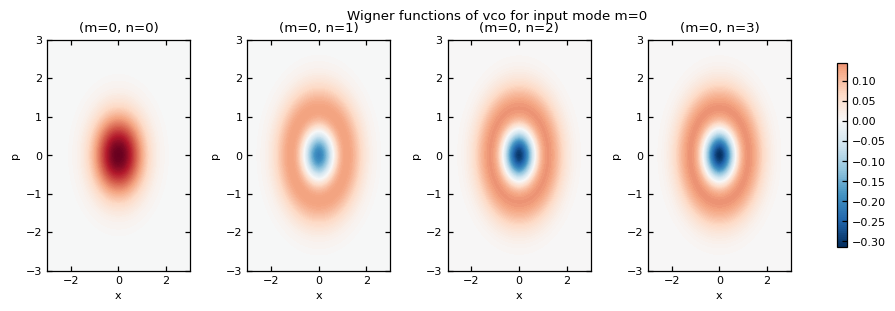

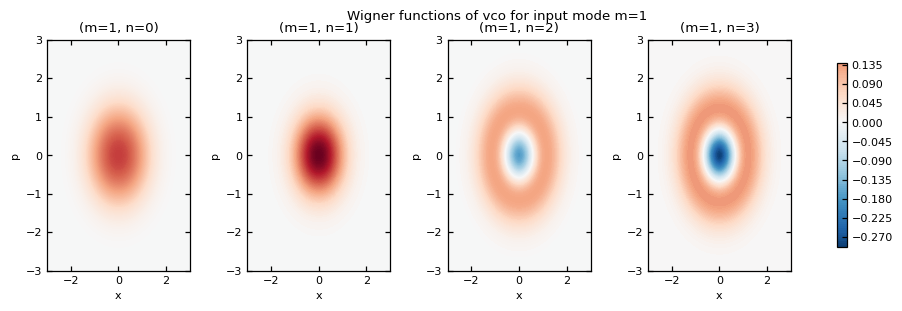

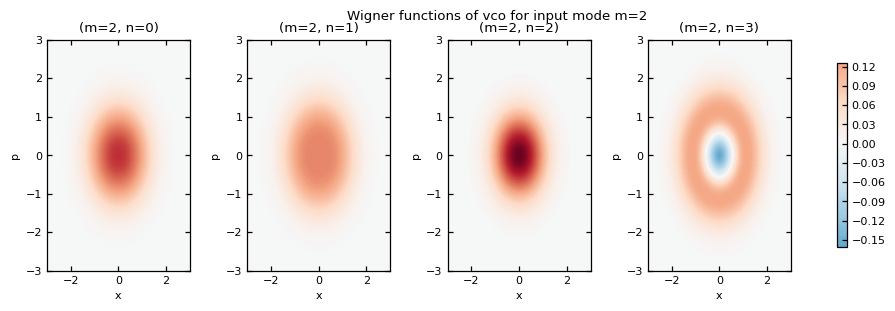

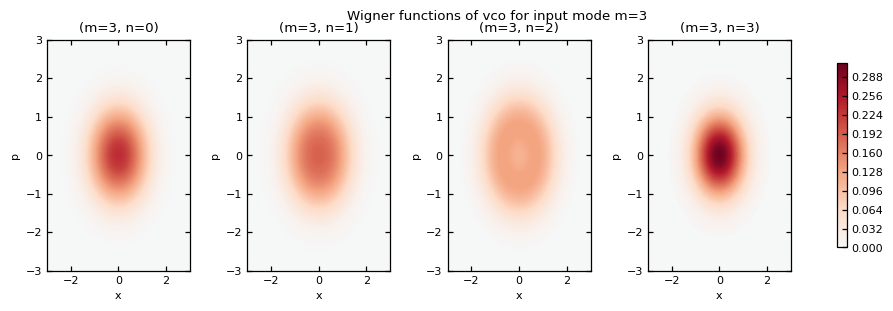

In [202]:
xvec = np.linspace(-3, 3, 200)

# まず全 Wigner 関数を計算してリストに保存
W_all = []
for m in range(4):
    for n in range(4):
        rho_total = results[(m, n)].states[-1]
        rho_vco = rho_total.ptrace(3)
        W_vco = qt.wigner(rho_vco, xvec, xvec)
        W_all.append(W_vco)

# 全16個の最小値と最大値を取得
W_stack = np.array(W_all)
vmin = W_stack.min()
vmax = W_stack.max()

# プロット
for m in range(4):
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    plt.subplots_adjust(wspace=0.4)
    
    for n in range(4):
        W_vco = W_all[m*4 + n]
        im = axes[n].contourf(xvec, xvec, W_vco, 100, cmap="RdBu_r", vmin=vmin, vmax=vmax)
        axes[n].set_xlabel("x")
        axes[n].set_ylabel("p")
        axes[n].set_title(f"(m={m}, n={n})")
    
    fig.colorbar(im, ax=axes.ravel(), shrink=0.8)
    plt.suptitle(f"Wigner functions of vco for input mode m={m}")
    plt.show()


## delay dependence

In [14]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

T = 1000 
N = 1001
tgrid = np.linspace(-T, T, N)
dt = tgrid[1] - tgrid[0]
# kappa_ph = 2.5e-3 * 2 * np.pi * 2

_eps = 1e-14

g_interps = []
g_interps_rvs = []

for m in range(8): 
    f_vals = f(tgrid, m, kappa_ph)
    f_prime_vals = f_prime(tgrid, m, kappa_ph) 
    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, tgrid, initial=0)

    numerator = f_prime_vals + (kappa_r * f_vals / 2)
    denominator = np.sqrt(kappa_r * (1.0 - integral_vals) - f2_vals)
    g_vals = numerator / denominator
    g_interp = interp1d(tgrid, np.real(g_vals), kind='cubic', fill_value='extrapolate')
    g_interps.append(g_interp)

    g_interp_rvs = interp1d(tgrid, np.real(g_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    g_interps_rvs.append(g_interp_rvs)
    
g_u_interps = []
for m in range(8):
    ut_vals = xi_m(tgrid, m, kappa_ph)
    # ut_vals = hermite(tgrid, m, kappa_ph)
    cumint = cumulative_trapezoid(np.abs(ut_vals)**2, tgrid, initial=0)
    eps = 1e-14
    denom = np.sqrt(1.0 - cumint + eps)
    g_vals = np.conjugate(ut_vals) / denom
    g_interp = interp1d(tgrid, g_vals, kind='cubic', fill_value='extrapolate')
    g_u_interps.append(g_interp)

def g_u(t, args):
    m = int(args["input_num"])
    t_local = float(t)
    return float(args["g_u_interps"][m](t_local))

def g_u_conj(t, args):
    return np.conjugate(g_u(t, args))

def g_time(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps"][m](t_local))

def g_time_conj(t, args):
    return np.conjugate(g_time(t, args))

def g_time_rvs(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps_rvs"][m](t_local))

def g_time_conj_rvs(t, args):
    return np.conjugate(g_time_rvs(t, args))

In [15]:
base_args = {
    "center": 0.0,
    "fogi_mode": 0,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 1,
}
results = {} 

for m in range(8):
    args_mn = base_args.copy()
    args_mn["input_num"] = m
    n=0

    H_m = [
        H_fogi,
        [H_c, g_u], [H_c.dag(), g_u_conj],
        [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
    ]
    psi0_m = vc1

    def total_c_op(t, args):
        c_op = np.conjugate(g_u(t, args)) * vc + np.sqrt(kappa_r) * a
        return c_op

    c_ops_mn = [
        total_c_op,
        np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
        np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
    ]

    result_mn = qt.mesolve(
        H_m, psi0_m, tgrid, c_ops_mn, e_ops=e_ops,
        args=args_mn, options=options, progress_bar=True
    )

    results[(m, n)] = result_mn 
    print(f"mode {m} finished")


c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


10.0%. Run time:   1.21s. Est. time left: 00:00:00:10
20.0%. Run time:   2.18s. Est. time left: 00:00:00:08
30.0%. Run time:   3.06s. Est. time left: 00:00:00:07
40.0%. Run time:   3.91s. Est. time left: 00:00:00:05
50.0%. Run time:   4.80s. Est. time left: 00:00:00:04
60.0%. Run time:   5.75s. Est. time left: 00:00:00:03
70.0%. Run time:   6.64s. Est. time left: 00:00:00:02
80.0%. Run time:   7.51s. Est. time left: 00:00:00:01
90.0%. Run time:   8.37s. Est. time left: 00:00:00:00
100.0%. Run time:   9.25s. Est. time left: 00:00:00:00
Total run time:   9.25s
mode 0 finished
10.0%. Run time:   0.90s. Est. time left: 00:00:00:08
20.0%. Run time:   1.77s. Est. time left: 00:00:00:07
30.0%. Run time:   2.65s. Est. time left: 00:00:00:06
40.0%. Run time:   3.55s. Est. time left: 00:00:00:05
50.0%. Run time:   4.42s. Est. time left: 00:00:00:04
60.0%. Run time:   5.33s. Est. time left: 00:00:00:03
70.0%. Run time:   6.66s. Est. time left: 00:00:00:02
80.0%. Run time:   7.54s. Est. time left:

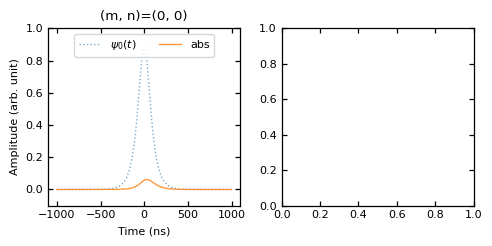

best_x: [-56.]


C:\Users\qipe\AppData\Local\Temp\ipykernel_27444\3965529470.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  overlap = np.trapz(np.conjugate(psi_prime) * shifted, dx=dt)


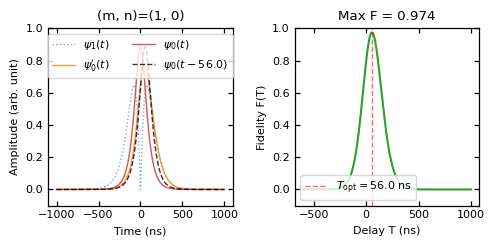

best_x: [-54.]


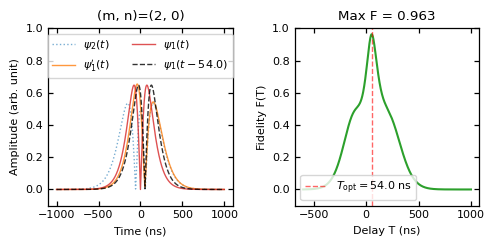

best_x: [-51.]


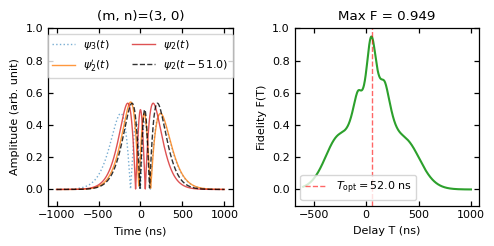

best_x: [-49.]


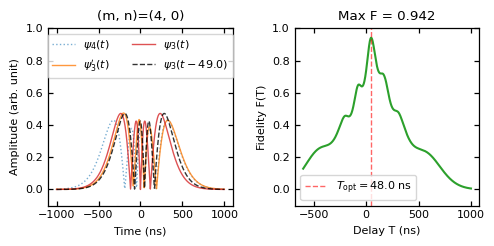

best_x: [-48.]


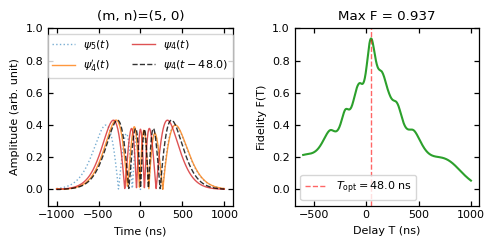

best_x: [-46.]


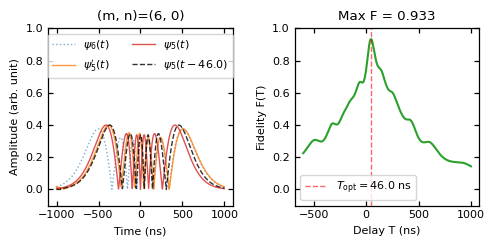

best_x: [-47.]


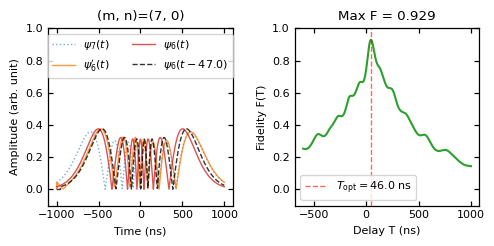

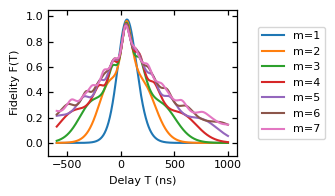

In [16]:
def fit_delay(time, waveform_exp, waveform_sim, x0=[0.0]):
    def func(params):
        shift = params
        sim_shifted = roll_with_interpolation(waveform_sim, shift=-shift)
        return sim_shifted

    def cost_func(params):
        return np.linalg.norm(np.abs(func(params)) - np.abs(waveform_exp))

    best_x = optimize.minimize(cost_func, x0, method='Nelder-Mead').x
    print("best_x:", np.round(best_x*2, 0))

    fitted = func(best_x)
    return fitted, best_x

def fidelity_vs_delay(tgrid, psi_prime, psi_target, T_vals):
    """
    F(T) = |∫ psi'(t) * psi(t - T) dt|^2
    """
    dt = tgrid[1] - tgrid[0]
    F_list = []
    for T in T_vals:
        shifted = np.interp(tgrid, tgrid - T, psi_target, left=0.0, right=0.0)
        overlap = np.trapz(np.conjugate(psi_prime) * shifted, dx=dt)
        F_list.append(np.abs(overlap)**2)
    return np.array(F_list)

all_F_vals = []
mode_labels = []

for m in range(8):    
    fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
    plt.subplots_adjust(wspace=0.4)

    n=0
    states = results[(m, n)].states
    vcdvc_s = qt.expect(vc.dag() * vc, states)
    ada_s = qt.expect(a.dag() * a, states)
    vcda_s = qt.expect(vc.dag() * a, states)
    advc_s = qt.expect(a.dag() * vc, states)
    args = {
        "center": 0.0,
        "fogi_mode": n,
        "g_interps": g_interps,
        "g_interps_rvs": g_interps_rvs,
        "g_u_interps": g_u_interps,
        "input_num": m,
        "input": 0,
    }  

    gu_values = np.array([g_u(t, args) for t in tgrid])
    LdL = (
        gu_values * np.conjugate(gu_values) * vcdvc_s
        + kappa_r * ada_s
        + np.sqrt(kappa_r) * (gu_values * vcda_s + np.conjugate(gu_values) * advc_s)
    )
    input_xi = xi_m(tgrid, m, kappa_ph)
    
    axes[0].plot(tgrid, np.abs(input_xi)*1e1, lw=1, alpha=0.6, color="tab:blue", linestyle=":", label=rf"$\psi_{m}(t)$")
    if m ==0:
        axes[0].plot(tgrid, np.abs(np.sqrt(LdL))*1e1, lw=1, alpha=0.8, color="tab:orange", label="abs")
    if m > 0:
        axes[0].plot(tgrid, np.abs(np.sqrt(LdL))*1e1, lw=1, alpha=0.8, color="tab:orange", label=rf"$\psi_{m-1}'(t)$")
        shifted_xi = xi_m(tgrid, m-1, kappa_ph)
        axes[0].plot(tgrid, np.abs(shifted_xi)*1e1, lw=1, alpha=0.8, color="tab:red", label= rf"$\psi_{m-1}(t)$")

        fitted_dummy, best_x = fit_delay(tgrid, np.sqrt(LdL), shifted_xi, x0=[-50])
        shift_val = best_x
        def apply_fit(waveform, shift_val, time):
            waveform_resampled = np.interp(time, np.linspace(time[0], time[-1], len(waveform)), waveform)
            dt = time[1] - time[0]
            shift_idx = -shift_val / dt 
            return nd_shift(waveform_resampled, shift=shift_idx, mode='constant', cval=0.0)
        
        delay_opt_waveform = apply_fit(shifted_xi, shift_val*2, tgrid)
        axes[0].plot(tgrid, np.abs(delay_opt_waveform)*1e1, lw=1, alpha=0.8, color="black", linestyle="--", label=rf"$\psi_{m-1}(t{round(shift_val[0]*2, 0)})$")

        T_vals = np.linspace(-600, 1000, 801)  # ns範囲
        F_vals = fidelity_vs_delay(tgrid, np.sqrt(LdL), np.abs(shifted_xi), -T_vals)
        all_F_vals.append(F_vals)
        mode_labels.append(f"m={m}")
        axes[1].plot(T_vals, F_vals, lw=1.5, color="tab:green")
        axes[1].set_xlabel("Delay T (ns)")
        axes[1].set_ylabel("Fidelity F(T)")
        axes[1].set_ylim(-0.1, 1)
        axes[1].set_title("Fidelity vs Delay")
        F_max = F_vals.max()
        T_opt = T_vals[F_vals.argmax()]
        axes[1].axvline(T_opt, color="red", linestyle="--", alpha=0.6, label=fr"$T_\mathrm{{opt}}={T_opt:.1f}$ ns")
        axes[1].legend(loc="lower left",)
        axes[1].set_title(fr"Max F = {F_max:.3f}")
     
    axes[0].set_xlabel(r"Time (ns)")
    axes[0].set_ylim(-0.1, 1)
    if n == 0:
        axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1), ncol=2)
        axes[0].set_ylabel("Amplitude (arb. unit)")
        axes[0].set_title(f"(m, n)=({m}, {n})")
    else:
        axes[0].set_title(f"({m}, {n})")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(4,2))
for F_vals, label in zip(all_F_vals, mode_labels):
    plt.plot(T_vals, F_vals, lw=1.5, label=label)
plt.xlabel("Delay T (ns)")
plt.ylabel("Fidelity F(T)")
plt.ylim(-0.1, 1.05)
# plt.title("Fidelity vs Delay for all modes")
plt.legend(loc="center right", bbox_to_anchor=(1.5, 0.5), ncol=1)
plt.tight_layout()
plt.show()

## mode preservation

In [17]:
base_args = {
    "center": 0.0,
    "fogi_mode": 7,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 1,
}
results = {} 

for m in range(8):
    args_mn = base_args.copy()
    args_mn["input_num"] = m
    n=0

    H_m = [
        H_fogi,
        [H_c, g_u], [H_c.dag(), g_u_conj],
        [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
    ]
    psi0_m = vc1

    def total_c_op(t, args):
        c_op = np.conjugate(g_u(t, args)) * vc + np.sqrt(kappa_r) * a
        return c_op

    c_ops_mn = [
        total_c_op,
        np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
        np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
    ]

    result_mn = qt.mesolve(
        H_m, psi0_m, tgrid, c_ops_mn, e_ops=e_ops,
        args=args_mn, options=options, progress_bar=True
    )

    results[(m, n)] = result_mn 
    print(f"mode {m} finished")


10.0%. Run time:   1.13s. Est. time left: 00:00:00:10
20.0%. Run time:   2.13s. Est. time left: 00:00:00:08
30.0%. Run time:   3.81s. Est. time left: 00:00:00:08
40.0%. Run time:   4.94s. Est. time left: 00:00:00:07
50.0%. Run time:   7.56s. Est. time left: 00:00:00:07
60.0%. Run time:   8.60s. Est. time left: 00:00:00:05
70.0%. Run time:  11.42s. Est. time left: 00:00:00:04
80.0%. Run time:  12.40s. Est. time left: 00:00:00:03
90.0%. Run time:  13.41s. Est. time left: 00:00:00:01
100.0%. Run time:  15.12s. Est. time left: 00:00:00:00
Total run time:  15.12s
mode 0 finished
10.0%. Run time:   0.98s. Est. time left: 00:00:00:08
20.0%. Run time:   1.96s. Est. time left: 00:00:00:07
30.0%. Run time:   3.50s. Est. time left: 00:00:00:08
40.0%. Run time:   4.43s. Est. time left: 00:00:00:06
50.0%. Run time:   5.40s. Est. time left: 00:00:00:05
60.0%. Run time:   6.32s. Est. time left: 00:00:00:04
70.0%. Run time:   7.24s. Est. time left: 00:00:00:03
80.0%. Run time:   8.14s. Est. time left:

best_x: [-5.]


C:\Users\qipe\AppData\Local\Temp\ipykernel_27444\3965529470.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  overlap = np.trapz(np.conjugate(psi_prime) * shifted, dx=dt)


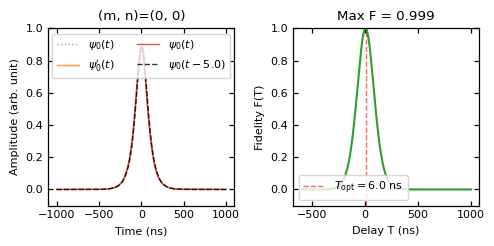

best_x: [-5.]


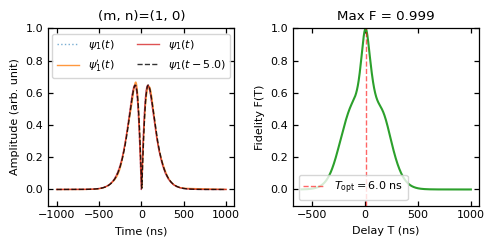

best_x: [-107.]


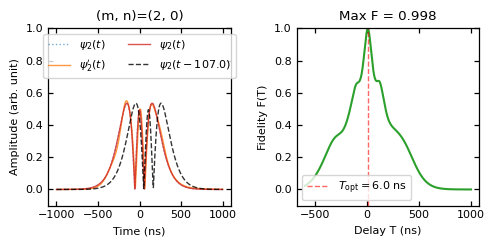

best_x: [-109.]


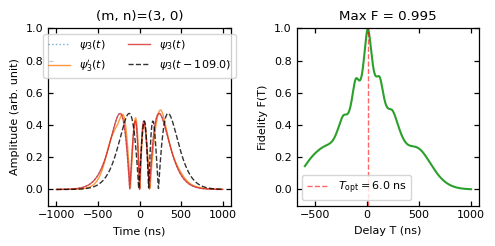

best_x: [-100.]


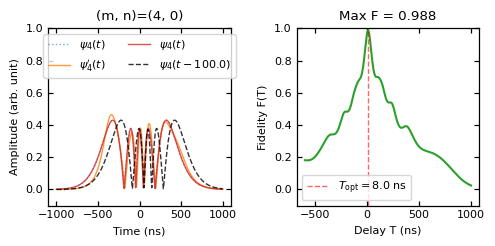

best_x: [-10.]


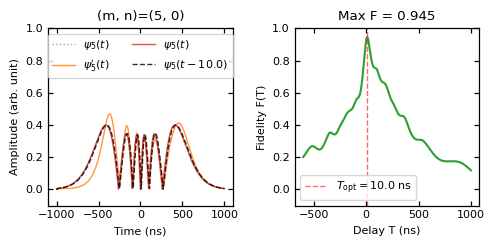

best_x: [-26.]


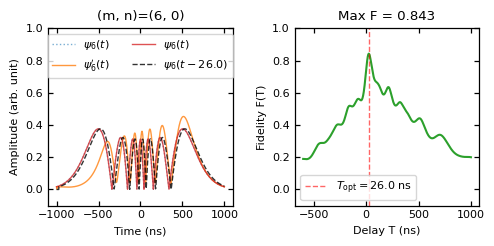

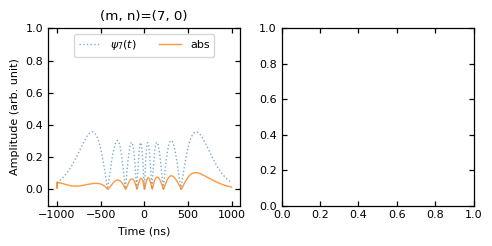

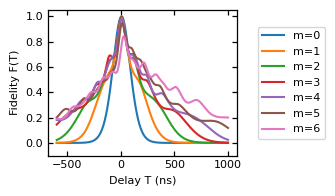

In [21]:
all_F_vals = []
mode_labels = []

for m in range(8):    
    fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
    plt.subplots_adjust(wspace=0.4)

    n=0
    states = results[(m, n)].states
    vcdvc_s = qt.expect(vc.dag() * vc, states)
    ada_s = qt.expect(a.dag() * a, states)
    vcda_s = qt.expect(vc.dag() * a, states)
    advc_s = qt.expect(a.dag() * vc, states)
    args = {
        "center": 0.0,
        "fogi_mode": n,
        "g_interps": g_interps,
        "g_interps_rvs": g_interps_rvs,
        "g_u_interps": g_u_interps,
        "input_num": m,
        "input": 0,
    }  

    gu_values = np.array([g_u(t, args) for t in tgrid])
    LdL = (
        gu_values * np.conjugate(gu_values) * vcdvc_s
        + kappa_r * ada_s
        + np.sqrt(kappa_r) * (gu_values * vcda_s + np.conjugate(gu_values) * advc_s)
    )
    input_xi = xi_m(tgrid, m, kappa_ph)
    
    axes[0].plot(tgrid, np.abs(input_xi)*1e1, lw=1, alpha=0.6, color="tab:blue", linestyle=":", label=rf"$\psi_{m}(t)$")
    if m ==7:
        axes[0].plot(tgrid, np.abs(np.sqrt(LdL))*1e1, lw=1, alpha=0.8, color="tab:orange", label="abs")
    if m < 7:
        axes[0].plot(tgrid, np.abs(np.sqrt(LdL))*1e1, lw=1, alpha=0.8, color="tab:orange", label=rf"$\psi_{m}'(t)$")
        nonshifted_xi = xi_m(tgrid, m, kappa_ph)
        axes[0].plot(tgrid, np.abs(nonshifted_xi)*1e1, lw=1, alpha=0.8, color="tab:red", label= rf"$\psi_{m}(t)$")

        fitted_dummy, best_x = fit_delay(tgrid, np.sqrt(LdL), nonshifted_xi, x0=[-50])
        shift_val = best_x
        def apply_fit(waveform, shift_val, time):
            waveform_resampled = np.interp(time, np.linspace(time[0], time[-1], len(waveform)), waveform)
            dt = time[1] - time[0]
            shift_idx = -shift_val / dt 
            return nd_shift(waveform_resampled, shift=shift_idx, mode='constant', cval=0.0)
        
        delay_opt_waveform = apply_fit(nonshifted_xi, shift_val*2, tgrid)
        axes[0].plot(tgrid, np.abs(delay_opt_waveform)*1e1, lw=1, alpha=0.8, color="black", linestyle="--", label=rf"$\psi_{m}(t{round(shift_val[0]*2, 0)})$")

        T_vals = np.linspace(-600, 1000, 801)  # ns範囲
        F_vals = fidelity_vs_delay(tgrid, np.sqrt(LdL), np.abs(nonshifted_xi), -T_vals)
        all_F_vals.append(F_vals)
        mode_labels.append(f"m={m}")
        axes[1].plot(T_vals, F_vals, lw=1.5, color="tab:green")
        axes[1].set_xlabel("Delay T (ns)")
        axes[1].set_ylabel("Fidelity F(T)")
        axes[1].set_ylim(-0.1, 1)
        axes[1].set_title("Fidelity vs Delay")
        F_max = F_vals.max()
        T_opt = T_vals[F_vals.argmax()]
        axes[1].axvline(T_opt, color="red", linestyle="--", alpha=0.6, label=fr"$T_\mathrm{{opt}}={T_opt:.1f}$ ns")
        axes[1].legend(loc="lower left",)
        axes[1].set_title(fr"Max F = {F_max:.3f}")
     
    axes[0].set_xlabel(r"Time (ns)")
    axes[0].set_ylim(-0.1, 1)
    if n == 0:
        axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1), ncol=2)
        axes[0].set_ylabel("Amplitude (arb. unit)")
        axes[0].set_title(f"(m, n)=({m}, {n})")
    else:
        axes[0].set_title(f"({m}, {n})")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(4,2))
for F_vals, label in zip(all_F_vals, mode_labels):
    plt.plot(T_vals, F_vals, lw=1.5, label=label)
plt.xlabel("Delay T (ns)")
plt.ylabel("Fidelity F(T)")
plt.ylim(-0.1, 1.05)
# plt.title("Fidelity vs Delay for all modes")
plt.legend(loc="center right", bbox_to_anchor=(1.5, 0.5), ncol=1)
plt.tight_layout()
plt.show()

0129

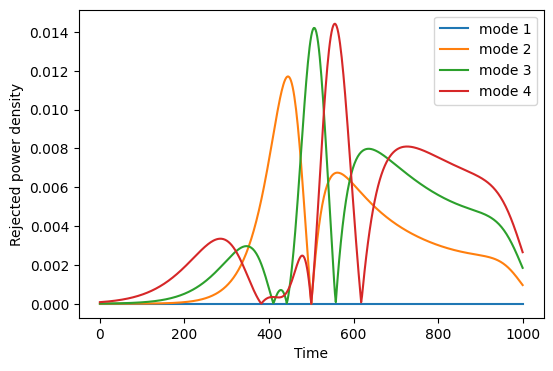

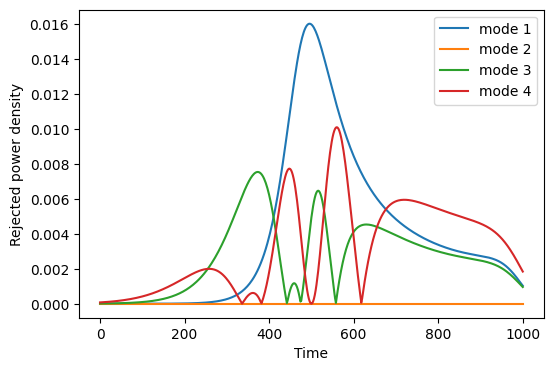

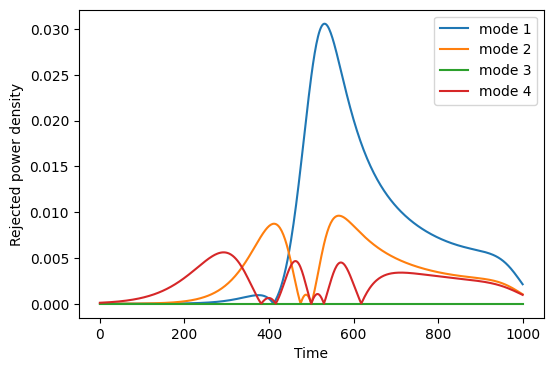

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# サンプルの直交モード
kappa_ph = 2.5e-3*2*np.pi*2
t = np.linspace(0, 1000, 501)
m1 =   xi_m(t-(t_vals[-1]-t_vals[0])/2, 0, kappa_ph)    # 正弦モード1
m2 =   xi_m(t-(t_vals[-1]-t_vals[0])/2, 1, kappa_ph) 
m3 =   xi_m(t-(t_vals[-1]-t_vals[0])/2, 2, kappa_ph)    # 正弦モード1
m4 =   xi_m(t-(t_vals[-1]-t_vals[0])/2, 3, kappa_ph)     # 正弦モード2
modes = [m1, m2, m3, m4]


plt.figure(figsize=(6,4))
for i, m in enumerate(modes):
    integral = np.cumsum(np.abs(m)**2) * (t[1]-t[0])
    integral_1 = np.cumsum(np.abs(m1)**2) * (t[1]-t[0])
    f = np.abs(m)**2 / (1 - integral + 1e-12)  # 0割防止
    g =  m / np.sqrt((1 - integral + 1e-12))*m1 / np.sqrt((1 - integral_1 + 1e-12))
    plt.plot(t, np.abs(f-g), label=f'mode {i+1}')

plt.xlabel('Time')
plt.ylabel('Rejected power density')
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
for i, m in enumerate(modes):
    integral = np.cumsum(np.abs(m)**2) * (t[1]-t[0])
    integral_2 = np.cumsum(np.abs(m2)**2) * (t[1]-t[0])
    f = np.abs(m)**2 / (1 - integral + 1e-12)  # 0割防止
    g =  m / np.sqrt((1 - integral + 1e-12))*m2 / np.sqrt((1 - integral_2 + 1e-12))
    plt.plot(t, np.abs(f-g), label=f'mode {i+1}')

plt.xlabel('Time')
plt.ylabel('Rejected power density')
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
for i, m in enumerate(modes):
    integral = np.cumsum(np.abs(m)**2) * (t[1]-t[0])
    integral_3 = np.cumsum(np.abs(m3)**2) * (t[1]-t[0])
    f = np.abs(m)**2 / (1 - integral + 1e-12)  # 0割防止
    g =  m / np.sqrt((1 - integral + 1e-12))*m3 / np.sqrt((1 - integral_3 + 1e-12))
    plt.plot(t, np.abs(f-g), label=f'mode {i+1}')

plt.xlabel('Time')
plt.ylabel('Rejected power density')
plt.legend()
plt.show()

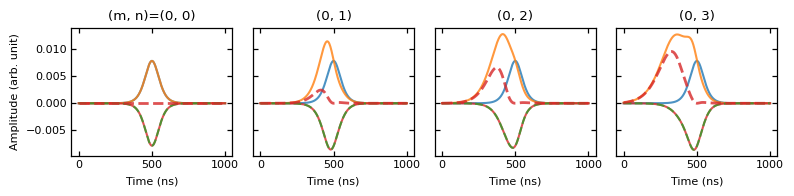

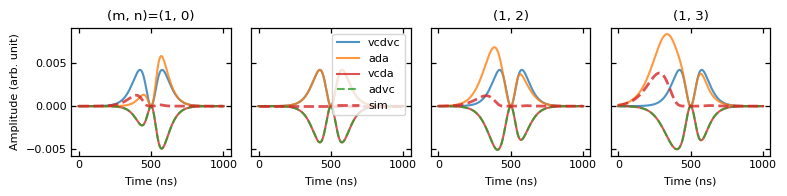

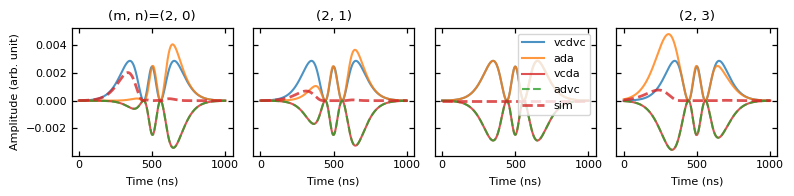

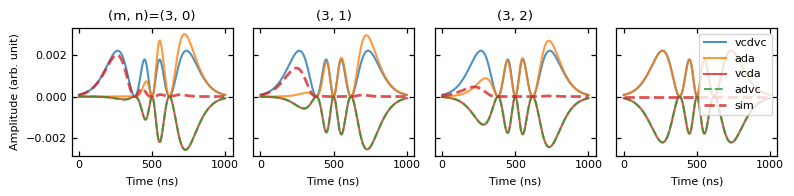

In [143]:
import numpy as np
import matplotlib.pyplot as plt

# 例: 既存のモード f を持っている前提
# modes = [m1, m2, m3, m4] の正規化済み f

dt = t[1] - t[0]
g_ph_modes = []
g_f0g1_modes = []

integrals=[]
integrals_f0g1=[]
delay=0
for m in modes:
    # 正規化（再確認用）
    integral = np.cumsum(np.abs(m)**2) * dt
    f = m / np.sqrt(1 - integral + 1e-12)  # 0割防止
    g_ph_modes.append(f)

    # 時間反転
    g_f0g1 = f[::-1]  # シンプルに反転
    g_f0g1_shifted = np.roll(g_f0g1, delay)
    # 先頭にシフト分を0パディング
    g_f0g1_shifted[:delay] = 0
    g_f0g1_modes.append(g_f0g1_shifted)
    integrals.append(integral)
    integral_f0g1_shifted = np.roll(integral[::-1], delay)
    integral_f0g1_shifted[:delay] = 0
    integrals_f0g1.append(integral_f0g1_shifted)


for m in range(4):    
    fig, axes = plt.subplots(1, 4, figsize=(8, 2), sharey=True)
    plt.subplots_adjust(wspace=0.4)

    for n in range(4):
        gu_values = np.array([g_u(t, args) for t in tgrid])
        # LdL = (
        #     g_ph_modes[m] * g_ph_modes[m]
        #     + g_ph_modes[n] * g_ph_modes[n]
        #     - g_ph_modes[m] * g_ph_modes[n]  - g_ph_modes[m] * g_ph_modes[n]
        # )*(1 - integrals[m] + 1e-12)
        vcdvc = (
            g_ph_modes[m] * g_ph_modes[m]*(1 - integrals[m] + 1e-12)
        )
        ada = (
            g_f0g1_modes[m] * g_f0g1_modes[m]*(1 - integrals_f0g1[n] + 1e-12)
            
        )
        vcda = (
            -np.abs(g_ph_modes[m] * g_f0g1_modes[m])*np.sqrt(1 - integrals[m] + 1e-12)*np.sqrt(1 - integrals_f0g1[n] + 1e-12)
        )
        advc = (
            -np.abs(g_ph_modes[m] * g_f0g1_modes[m])*np.sqrt(1 - integrals[m] + 1e-12)*np.sqrt(1 - integrals_f0g1[n] + 1e-12)
        )
        LdL = vcdvc + ada+ vcda + advc
        # abs_exp = acquisitions[m][n].get_results()["y_absorbed_signals"][ph_amp][fogi_freq][100:-149]
        # fitted_dummy, best_x = fit_waveform(tgrid, np.abs(abs_exp), np.sqrt(LdL), x0=[1.0, 10.0])
        # scale, shift_val = best_x
        # def apply_fit(waveform, scale, shift_val, time):
        #     waveform_resampled = np.interp(time, np.linspace(time[0], time[-1], len(waveform)), waveform)
        #     dt = time[1] - time[0]
        #     shift_idx = -shift_val / dt 
        #     return scale * nd_shift(waveform_resampled, shift=shift_idx, mode='constant', cval=0.0)
        
        # fitted_abs_sim = apply_fit(np.sqrt(LdL), scale, shift_val, tgrid)
            
        # axes[n].plot(tgrid, np.abs(abs_exp)*1e3, lw=4, alpha=0.6, color="tab:blue", label="exp")
        # axes[n].plot(tgrid, np.abs(fitted_abs_sim)*1e3, lw=2, alpha=0.8, linestyle="--", color="tab:red", label="sim")
        
        axes[n].plot(t, vcdvc, lw=1.5, alpha=0.8, color="tab:blue", label="vcdvc")
        axes[n].plot(t, ada, lw=1.5, alpha=0.8, color="tab:orange", label="ada")
        axes[n].plot(t, vcda, lw=1.5, alpha=0.8, color="tab:red", label="vcda")
        axes[n].plot(t, advc, lw=1.5, alpha=0.8, linestyle="--", color="tab:green", label="advc")
        axes[n].plot(t, LdL, lw=2, alpha=0.8, linestyle="--", color="tab:red", label="sim")
        axes[n].set_xlabel(r"Time (ns)")
        if n == 0:
            axes[n].set_ylabel("Amplitude (arb. unit)")
            axes[n].set_title(f"(m, n)=({m}, {n})")
        elif n==m:
            axes[n].legend(loc='upper right')
        else:
            axes[n].set_title(f"({m}, {n})")
    plt.tight_layout()
    plt.show()

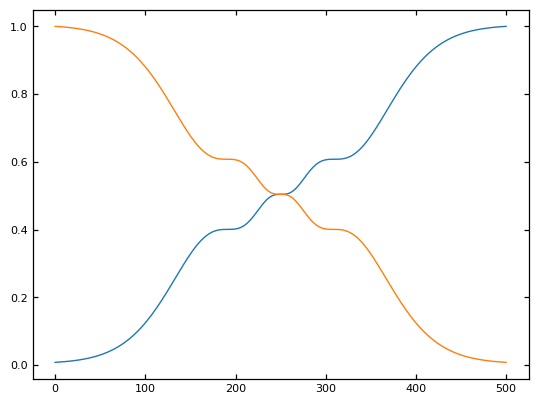

In [122]:
plt.plot((1 - integrals_f0g1[n] + 1e-12))
plt.plot((1 - integrals[n] + 1e-12))